# Rud Gallium MFA - Main Notebook

**Student**
- Name: Rud Hansen
- Leiden Stud.Nr.: s4946766
- Delft Stud.Nr.: 6605354

**Date of submission deadline:** 2026/06/26

## Introduction

Material flow analysis (MFA) of gallium embodied in electronics components imported to the EU. 
Applying scenarios for different EU strategies to evaluate the research question:
- RQ: How do EU strategies for Critical Raw Materials and production of semiconductors reshape the EU gallium system, focusing on imported electronics semiconductor components products?
    - Sub-RQ: How do import dependencies change when implementing EU strategies for self-sufficiency?

For a workflow diagram of the model, please refer to the poster: [link to pdf on GitHub](https://github.com/Rud-X/IE_MFA_2526_FinalAssignment_Gallium/blob/6c9540cc1a5a26f54235bdd79119f6c033c5e0cf/poster_info/Rud_Hansen_A1_color_v2.pdf)

## Notebook introduction

This notebook contains all the code necessary to run the model and generate the plots used for the poster, as well as plots for debugging of the model.

GitHub repository: https://github.com/Rud-X/IE_MFA_2526_FinalAssignment_Gallium

### How to run

The code is hosted as a repository on GitHub. The easiest is to clone the repository and run the notebook, this puts the data source in the right place and makes sure all necessary folders are created.

GitHub repository: https://github.com/Rud-X/IE_MFA_2526_FinalAssignment_Gallium

Else make sure to place the data file (`EUROSTAT_COMEXT_20260622_1.csv`) in a folder called `data`. 

You can just try and run all cells, this will create the folders and then exit with an error, if the data file is not there.

### Notebook structure explanation

The notebook is quite long and is best understood by following the markdown heading structure (or opening the Read-the-docs/HTML documentation, see below). 

All the functionality is basicly packaged in different functions to make it more reproducable and the latter steps (scenario modelling and sensitivity analysis) easily executable and extendable. Nearly all functions are documented with Google-style docstring documentation, which is the primary documentation of the functions.

Here is a brief introduction to the notebook structure:
|Section|Description|
|---|---|
|## Initial import and setup|Imports packages and sets up folder structure|
|## ETL EUROSTAT data| Extract Transform and Load the EUROSTAT COMEXT data (the trade data)|
|## MFA functionality|Includes all the functions for running the different MFA models, calculate life-cycle, etc., including different helper functions|
|## Configure product lifecycle info, data, and assumptions|Setup which products to look at and their information (product codes, marketshare, material intensity, survival curve, transfercoefficients). Also list the most important assumptions about products and lifecycle|
|## Functions: Scenarios|Functions to create import scenario |
|## Scenario setup and initial model run|Define parameters for scenarios and run the model once to check that everything is working (Annoyed with all the plots? Change `detailed_plot=False` for the function `run_main_MFA`, this silences the plotting)|
|## Main run scenarios|Runs the the model for the 4 different scenarios|
|## Main run sensitivity|Runs a simple sensitivity analysis|
|## Extra figures for poster|Plots and saves (to /plots) different plots used on the poster|

### Read-the-docs/HTML documentation

For translating the docs-string documentation in this file into a more readable format, there is a /docs folder in the GitHub repository, that generates a read-the-docs html file.

To run: `./docs/build_docs.sh`

HTML location: `docs/build/index.html`

## AI-statement
Generative AI has been used as a supporting tool for refining and defining code, but the developer/student (Rud Hansen) takes full responsibility for the content and functionality.

For generating the functionality in `docs/` generative AI was used more extensively. This folder is available through the GitHub repository and has functionality for running the documentation workflow, generating the read-the-docs/HTML.


## Initial import and setup

In [46]:
##### Initial import and setup #####
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import plotly
import copy

# Ignore warnings for cleaner output
import warnings

warnings.filterwarnings("ignore", "Workbook contains no default style", UserWarning)

In [47]:
# Check that /plots directory exists, if not create it
if not os.path.exists("plots"):
    warnings.warn("Warning: /plots directory not found. Creating it now.")
    os.makedirs("plots")

# Check that /data directory exists, if not create it
if not os.path.exists("data"):
    warnings.warn("Warning: /data directory not found. Creating it now.")
    os.makedirs("data")

# Check if /data directory contains the required file(s), if not exit with error
required_files = ["data/EUROSTAT_COMEXT_20260622_1.csv"]
for file in required_files:
    if not os.path.exists(file):
        sys.exit(
            f"Error: Required file {file} not found in /data directory.\n"
            "Please download it and place it in the /data directory.\n"
            "Or just clone the repository from GitHub: https://github.com/Rud-X/IE_MFA_2526_FinalAssignment_Gallium"
        )


## ETL EUROSTAT data
### Extract and Transform: EUROSTAT COMEXT data

In [48]:
# Load data/EUROSTAT_COMEXT.csv into a DataFrame
comext_df = pd.read_csv("data/EUROSTAT_COMEXT_20260622_1.csv")

# Select relevant columns
selected_columns = [
    "reporter",
    "partner",
    "product",
    "PRODUCT",
    "flow",
    "FLOW",
    "indicators",
    "TIME_PERIOD",
    "OBS_VALUE",
]

# Copy dataframe only with selected columns
eurostat_df = comext_df[selected_columns].copy()

# Filter out "product" == "TOTAL"
eurostat_df = eurostat_df[eurostat_df["product"] != "TOTAL"]

# Format product (int) and OBS_VALUE (float) columns to numbers => To avoid errors later
eurostat_df["product"] = eurostat_df["product"].astype(int)
eurostat_df["OBS_VALUE"] = eurostat_df["OBS_VALUE"].astype(float)


### Functions: Load EUROSTAT COMEXT data
Based on product selection

In [49]:
def build_imp_exp_table(
    df, product_code, partner="EXT_EU27_2020", detailed_output=False
):
    """Build a yearly import/export/net-flow table (in kg) for a given product code.
    Using the COMEXT dataframe. Filters and pivots dataframe.

    Args:
        df: COMEXT DataFrame containing at least the columns
            "product", "indicators", "partner", "FLOW", "TIME_PERIOD",
            and "OBS_VALUE".
        product_code: Product code (as used in the "product" column) to
            filter the data on. May be a single code or a list/tuple of
            codes in which case their flows are summed together.
        partner: Trade partner code to filter on. Defaults to
            "EXT_EU27_2020" (extra-EU27 trade).
        detailed_output: If True, displays intermediate DataFrames for inspection.

    Returns:
        DataFrame: One row per TIME_PERIOD with columns "TIME_PERIOD",
        "Exports_kg", "Imports_kg", and "Net_Flow_kg" (which is Imports - Exports).
    """
    # Indicator to select and factor for scaling to kg
    indicator = "QUANTITY_IN_100KG"
    scale_to_kg = 100

    # Normalize to a list so a single code and a list of codes are handled alike
    codes = product_code if isinstance(product_code, (list, tuple)) else [product_code]
    if detailed_output:
        display(df.head())
        display(
            f"Building import/export table for product codes: {codes} and partner: {partner}"
        )
    # Filter relevant records => Codes, indicator, partner
    filtered_df = df[
        (df["product"].isin(codes))
        & (df["indicators"] == indicator)
        & (df["partner"] == partner)
    ].copy()
    if filtered_df.empty:
        raise ValueError(
            f"No data found for product codes {codes} and partner {partner} with indicator {indicator}."
        )

    # Convert unit (e.g., 100kg -> kg)
    filtered_df["OBS_VALUE_KG"] = filtered_df["OBS_VALUE"] * scale_to_kg

    # Aggregate by year and flow => as_index=False to keep TIME_PERIOD as a column
    flow_df = filtered_df.groupby(["TIME_PERIOD", "FLOW"], as_index=False)[
        "OBS_VALUE_KG"
    ].sum()

    # Pivot to import/export columns
    pivot_df = flow_df.pivot(
        index="TIME_PERIOD", columns="FLOW", values="OBS_VALUE_KG"
    ).fillna(0)

    # Ensure both columns exist => if not, create them with 0 values
    for col in ["EXPORT", "IMPORT"]:
        if col not in pivot_df.columns:
            pivot_df[col] = 0

    # Rename columns and calculate net flow
    pivot_df = pivot_df.rename(columns={"EXPORT": "Exports_kg", "IMPORT": "Imports_kg"})
    pivot_df["Net_Flow_kg"] = pivot_df["Imports_kg"] - pivot_df["Exports_kg"]
    pivot_df = pivot_df.reset_index()
    if detailed_output:
        display(filtered_df)
        display(flow_df)
        display(pivot_df)

    # Return the final pivoted DataFrame
    return pivot_df


def plot_imp_exp_table(df, display_product_name):
    """Line-plot for inspection of imp_exp_table
    Shows a line for Exports_kg, Imports_kg, and
    Net_Flow_kg over TIME_PERIOD for a product.

    Args:
        df: DataFrame with columns "TIME_PERIOD", "Exports_kg",
            "Imports_kg", and "Net_Flow_kg" (e.g. as returned by
            build_imp_exp_table or translate_to_Ga_MI).
        display_product_name: Display name of the product, used in the plot title.

    Returns:
        None: Displays the plot via matplotlib. Does not return a value.
    """
    # Plot exports, imports, and net flow over time
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Exports_kg",
        marker="o",
        label="Exports (kg/y)",
    )
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Imports_kg",
        marker="o",
        label="Imports (kg/y)",
    )
    sns.lineplot(
        data=df,
        x="TIME_PERIOD",
        y="Net_Flow_kg",
        marker="o",
        label="Net Flow (kg/y)",
    )
    plt.title(f"{display_product_name} - EU\nExports, Imports, and Net Flow Over Time")
    plt.xlabel("Year")
    plt.ylabel("Quantity (kg/y)")
    plt.xticks(rotation=45, ticks=df["TIME_PERIOD"].unique())
    plt.legend()
    plt.grid()
    plt.show()

## MFA functionality
### Helpers: Products

In [50]:
def translate_to_Ga_MI(df, material_intensity_Ga, market_share=1.0):
    """Scale an Imports/Exports/Net_Flow (kg) table by a gallium material intensity factor.

    Args:
        df: DataFrame (imp_exp_table) with columns "Imports_kg", "Exports_kg",
            and "Net_Flow_kg" (e.g. as returned by build_imp_exp_table).
        material_intensity_Ga: Mass fraction (kg Ga per kg product) used to
            convert product mass flows into gallium mass flows.
        market_share: Fraction of the market to consider (default is 1.0 => 100%).

    Returns:
        pd.DataFrame: Copy of df with "Imports_kg", "Exports_kg",
        and "Net_Flow_kg" scaled by material_intensity_Ga (now representing
        gallium mass instead of product mass).
    """
    imp_exp_table_Ga = df.copy()
    imp_exp_table_Ga["Imports_kg"] = (
        df["Imports_kg"] * material_intensity_Ga * market_share
    )
    imp_exp_table_Ga["Exports_kg"] = (
        df["Exports_kg"] * material_intensity_Ga * market_share
    )
    imp_exp_table_Ga["Net_Flow_kg"] = (
        df["Net_Flow_kg"] * material_intensity_Ga * market_share
    )
    return imp_exp_table_Ga


### Functions: Flow driven model

In [51]:
def calculate_flow_driven_MFA(
    year_inflow_data,
    show_output=True,
    survival_curve_parameters=None,
    input_from_model=False,
):
    """Run a flow-driven MFA system based on historical inflow data.

    Given yearly inflow data and a survival curve.
    Builds stocks, outflows, and stock changes via mass balance.

    Optional plots.

    Nearly same code as Rud Hansen submitted in mini-assignment 3.

    Also nearly identical to calculate_stock_driven_MFA

    Process:

    1. Check survival_curve_parameters
    2. Input data into the model + survival curve
    3. Set up the MFA system
    4. Create the survival curves matrix
    5. Create the cohorts survival matrix
    6. Calculate the MFA system
    7. View and/or plot the full MFA system
    8. Return the MFA system with units

    Args:
        year_inflow_data: DataFrame with the columns "TIME_PERIOD"
            and "Net_Flow_kg", one row per year, used as the system inflows.
        show_output: Whether to display intermediate matrices and plots
            (survival curve, survival/cohort heatmaps, flows, stocks).
            Defaults to True.
        survival_curve_parameters: Dict describing the survival curve.
        input_from_model: Boolean indicating whether the input data is from another MFA model
            (True) or from historical data (False). Defaults to False.
    Returns:
        pd.DataFrame: MFA system with columns "stocks [kg]", "inflows [kg/year]",
            "outflows [kg/year]", and "stock_changes [kg/year]".
            Indexed by year.

    Raises:
        ValueError: If year_inflow_data is missing the required columns, or
            if survival_curve_parameters["type"] is not a recognized type.
    """
    # %% 1. Check survival_curve_parameters
    if survival_curve_parameters is None:
        raise ValueError("survival_curve_parameters must be provided.")

    # %% 2. input data into the model
    # Check columns of the input data
    if not input_from_model:
        expected_columns = {"TIME_PERIOD", "Net_Flow_kg"}
    else:
        expected_columns = {"year", "Net_Flow_kg"}
    if not expected_columns.issubset(year_inflow_data.columns):
        raise ValueError(
            f"Input data must contain the following columns: {expected_columns}"
        )

    # %%% 2.1 Prepare the input data - Keep only "TIME_PERIOD" and "Net_Flow_kg"
    if not input_from_model:
        input_data = year_inflow_data[["TIME_PERIOD", "Net_Flow_kg"]].copy()
        input_data = input_data.rename(
            columns={"TIME_PERIOD": "year", "Net_Flow_kg": "inflows"}
        )
    else:
        input_data = year_inflow_data[["year", "Net_Flow_kg"]].copy()
        input_data = input_data.rename(
            columns={"year": "year", "Net_Flow_kg": "inflows"}
        )
    # Format and set index
    input_data["year"] = input_data["year"].astype(int)
    input_data = input_data.set_index("year")["inflows"]

    # %%% 2.2 survival curve
    # Create ages of a cohort start at zero.
    ages = range(0, len(input_data))

    # Fixed lifetime / the delay model
    if survival_curve_parameters["type"] == "fixed_lifetime":
        lifetime = survival_curve_parameters["lifetime"]
        survival_curve = np.zeros_like(ages)
        survival_curve[0:lifetime] = 1
    # Weibull distribution survival curve
    elif survival_curve_parameters["type"] == "weibull":
        shape = survival_curve_parameters["alpha"]  # Shape
        scale = survival_curve_parameters["beta"]  # Scale
        survival_curve = scipy.stats.weibull_min.sf(ages, c=shape, scale=scale)
    # Normal distribution survival curve
    elif survival_curve_parameters["type"] == "normal":
        mean = survival_curve_parameters["mean"]
        std_dev = survival_curve_parameters["std_dev"]
        survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)
    # Geometric distribution survival curve / the leaching model
    elif survival_curve_parameters["type"] == "leaching":
        depreciation_rate = survival_curve_parameters["depreciation_rate"]
        survival_curve = scipy.stats.geom.sf(ages, depreciation_rate)
    # Uniform distribution survival curve / slope survival curve
    elif survival_curve_parameters["type"] == "uniform":
        uniform_removal = survival_curve_parameters["uniform_removal"]
        survival_curve = scipy.stats.uniform.sf(ages, loc=0, scale=1 / uniform_removal)
    # Log-normal distribution survival curve
    elif survival_curve_parameters["type"] == "lognormal":
        shape = survival_curve_parameters["shape"]  # Original values = 2
        location = survival_curve_parameters["location"]  # Original values = 0
        scale = survival_curve_parameters["scale"]  # Original values = 40
        survival_curve = scipy.stats.lognorm.sf(
            ages, s=shape, loc=location, scale=scale
        )
    else:
        raise ValueError("Invalid survival curve type.")

    # visualize the survival curve
    if show_output:
        plt.plot(ages, survival_curve)
        plt.xlabel("Age")
        plt.ylabel("Survival rate")
        plt.title("Survival curve")
        plt.show()

    # %% 3. Set up the MFA system

    units = {"time_interval": "year", "flows": "kg/year", "stocks": "kg"}

    timeframes = cohorts = (
        input_data.index
    )  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

    cohorts_end = (
        cohorts[-1] + 1
    )  # because of exclusive slicing in python, an extra time interval is required

    mfa_system = pd.DataFrame(
        index=timeframes, columns=["stocks", "inflows", "outflows", "stock_changes"]
    )

    mfa_system["inflows"] = input_data

    # %% 4. Create the survival curves matrix

    # create an initial survival curves matrix filled with zeros'
    survival_curves_matrix = pd.DataFrame(
        0, index=timeframes, columns=cohorts, dtype=float
    )

    # and populate that matrix, cohort by cohort.
    for cohort in cohorts:
        # at each iteration, fill a shifted survival curve (cut at its end) into the next column of the survival curves matrix, from the diagonal downwards. Leave the upper part with zeros.
        survival_curves_matrix.loc[cohort:, cohort] = survival_curve[
            0 : cohorts_end - cohort
        ]

    if show_output:
        display(round(survival_curves_matrix, 3))

        # Plot the survival curves matrix as a heatmap
        sns.heatmap(survival_curves_matrix, cbar_kws={"label": "Survival Probability"})
        plt.show()

    # %% 5. Create the cohorts survival matrix
    # initialize the cohort_survival_matrix filled with zeros
    cohorts_survival_matrix = pd.DataFrame(
        0, index=timeframes, columns=cohorts, dtype=float
    )

    # And populate it, cohort by cohort.
    for cohort in cohorts:
        # at each iteration, scale the shifted survival curve with the inflow of the time-th timeframe.
        cohorts_survival_matrix.loc[:, cohort] = (
            survival_curves_matrix.loc[:, cohort] * mfa_system["inflows"].loc[cohort]
        )

    if show_output:
        # and visualize the cohort_survival_matrix matrix with a heatmap
        sns.heatmap(cohorts_survival_matrix, annot=False)
        plt.show()

    # %% 6. Calculate the MFA system
    # %%% 6.1 Calculate stocks

    # the stocks are the sum of the surviving cohorts, which is the sum of cohorts survival matrix row by row.
    mfa_system["stocks"] = cohorts_survival_matrix.sum(axis="columns")

    # %%% 6.2 Calculate stock changes (nas)
    # stock_changes is the difference between two timeframes.
    # prepend=0 covers the convention that stock_change is the difference between current timeframe and previous timeframe.
    # without it, np.diff calculates the difference between current timeframe and next timeframe.
    mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)

    # %%% 6.3 Calculate outflows
    # using mass balance
    mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

    # %% 7. View the full MFA system
    # add the units of measurements
    mfa_system_with_units = mfa_system.rename(
        columns={
            "stocks": "stocks [" + units["stocks"] + "]",
            "inflows": "inflows [" + units["flows"] + "]",
            "outflows": "outflows [" + units["flows"] + "]",
            "stock_changes": "stock_changes [" + units["flows"] + "]",
        }
    )

    # %%% 7.1 Plot results
    if show_output:
        # plot flows
        mfa_system_with_units[
            ["inflows [kg/year]", "outflows [kg/year]", "stock_changes [kg/year]"]
        ].plot(ylabel="flows [kg/year]", color=["#2A8596", "#D19F37", "#8E795E"])
        plt.show()

        # plot stocks
        mfa_system_with_units["stocks [kg]"].plot(
            kind="area", stacked=True, ylabel="stocks [kg]", color="#DC322F"
        )
        plt.show()

        # plot stocks composition by cohorts
        cohorts_survival_matrix.plot(
            kind="area", stacked=True, legend=False, lw=0, ylabel="stocks [kg]"
        )
        plt.show()

    # %%% 8. Return the MFA system with units
    return mfa_system_with_units


### Functions: Stock driven model

In [52]:
def calculate_stock_driven_MFA(
    year_stock_data,
    show_output=True,
    survival_curve_parameters=None,
    input_from_model=False,
):
    """Run a stock-driven MFA system based on historical stock data.

    Given yearly stock data and a survival curve.
    Builds inflows, outflows, and stock changes via mass balance.

    Optional plots.

    Nearly same code as Rud Hansen submitted in mini-assignment 3.

    Also nearly identical to calculate_flow_driven_MFA

    Process:

    1. Check survival_curve_parameters
    2. Input data into the model + survival curve
    3. Set up the MFA system
    4. Create the survival curves matrix
    5. Create the cohorts survival matrix
    6. Calculate the MFA system
    7. View and/or plot the full MFA system
    8. Return the MFA system with units


    Args:
        year_stock_data: DataFrame with columns "TIME_PERIOD"
            and "stocks [kg]", one row per year, used as the system stocks.
        show_output: Whether to display intermediate outputs
            (survival curve, survival/cohort heatmaps, flows, stocks).
            Defaults to True.
        survival_curve_parameters: Dict describing the survival curve.
        input_from_model: Boolean indicating whether the input data is from another MFA model
            (True) or from historical data (False). Defaults to False.

    Returns:
        pd.DataFrame: MFA system with columns "stocks", "inflows",
            "outflows", "stock_changes"
            Indexed by year.

    Raises:
        ValueError: If year_stock_data is missing the required columns, or
            if survival_curve_parameters["type"] is not a recognized type.
    """
    # %% 1. Check survival_curve_parameters
    if survival_curve_parameters is None:
        raise ValueError("survival_curve_parameters must be provided.")

    # %% 2. input data into the model
    # Check columns of the input data
    if not input_from_model:
        expected_columns = {"TIME_PERIOD", "stocks [kg]"}
    else:
        expected_columns = {"year", "stocks [kg]"}
    if not expected_columns.issubset(year_stock_data.columns):
        raise ValueError(
            f"Input data must contain the following columns: {expected_columns}"
        )

    # %% 2.1 Prepare the input data - Keep only "TIME_PERIOD" and "stocks [kg]"
    if not input_from_model:
        input_data = year_stock_data[["TIME_PERIOD", "stocks [kg]"]].copy()
        input_data = input_data.rename(
            columns={"TIME_PERIOD": "year", "stocks [kg]": "stocks"}
        )
    else:
        input_data = year_stock_data[["year", "stocks [kg]"]].copy()
        input_data = input_data.rename(
            columns={"year": "year", "stocks [kg]": "stocks"}
        )
    # Format and set index
    input_data["year"] = input_data["year"].astype(int)
    input_data = input_data.set_index("year")["stocks"]

    # %%% 2.2 survival curve
    # Create ages of a cohort start at zero.
    ages = range(0, len(input_data))

    # Normal distribution survival curve
    if survival_curve_parameters["type"] == "normal":
        mean = survival_curve_parameters["mean"]
        std_dev = survival_curve_parameters["std_dev"]
        survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)
    # Geometric distribution survival curve / the leaching model
    elif survival_curve_parameters["type"] == "leaching":
        depreciation_rate = survival_curve_parameters["depreciation_rate"]
        survival_curve = scipy.stats.geom.sf(ages, depreciation_rate)
    # Fixed lifetime / the delay model
    elif survival_curve_parameters["type"] == "fixed":
        lifetime = survival_curve_parameters["lifetime"]
        survival_curve = np.zeros_like(ages)
        survival_curve[0:lifetime] = 1
    # Weibull distribution survival curve
    elif survival_curve_parameters["type"] == "weibull":
        shape = survival_curve_parameters["alpha"]  # Shape
        scale = survival_curve_parameters["beta"]  # Scale
        survival_curve = scipy.stats.weibull_min.sf(ages, c=shape, scale=scale)
    else:
        raise ValueError("Invalid survival curve type.")

    # visualize the survival curve
    if show_output:
        plt.plot(ages, survival_curve)
        plt.xlabel("Age")
        plt.ylabel("Survival rate")
        plt.title("Survival curve")
        plt.show()

    # %% 3. Set up the MFA system

    units = {"time_interval": "year", "flows": "kg/year", "stocks": "kg"}

    timeframes = cohorts = (
        input_data.index
    )  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

    cohorts_end = (
        cohorts[-1] + 1
    )  # because of exclusive slicing in python, an extra time interval is required

    mfa_system = pd.DataFrame(
        index=timeframes, columns=["stocks", "inflows", "outflows", "stock_changes"]
    )

    mfa_system["stocks"] = input_data

    # %% 4. Create the survival curves matrix

    # create an initial survival curves matrix filled with zeros
    survival_curves_matrix = pd.DataFrame(
        0, index=timeframes, columns=cohorts, dtype=float
    )

    # and populate that matrix, cohort by cohort.
    for cohort in cohorts:
        # at each iteration, fill a shifted survival curve (cut at its end) into the next column of the survival curves matrix, from the diagonal downwards. Leave the upper part with zeros.
        survival_curves_matrix.loc[cohort:, cohort] = survival_curve[
            0 : cohorts_end - cohort
        ]

    if show_output:
        display(round(survival_curves_matrix, 3))

        # Plot the survival curves matrix as a heatmap
        sns.heatmap(survival_curves_matrix, cbar_kws={"label": "Survival Probability"})
        plt.show()

    # %% 5. Create the cohorts survival matrix
    # initialize the cohort_survival_matrix filled with zeros
    cohorts_survival_matrix = pd.DataFrame(
        0, index=timeframes, columns=cohorts, dtype=float
    )

    # Populate it, cohort by cohort
    for cohort in cohorts:
        # calculate the inflow of the time-th year
        mfa_system.loc[cohort, "inflows"] = (
            mfa_system.loc[cohort, "stocks"]
            - cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
        ) / survival_curves_matrix.loc[cohort, cohort]
        # now that the time-th inflow is known, scale the shifted survival curve with this inflow to add a new cohort's survival to the cohorts survival matrix
        cohorts_survival_matrix.loc[:, cohort] = (
            survival_curves_matrix.loc[:, cohort] * mfa_system.loc[cohort, "inflows"]
        )

    if show_output:
        # and visualize the cohort_survival_matrix matrix with a heatmap
        sns.heatmap(cohorts_survival_matrix, annot=False)
        plt.show()

    # %% 6. Calculate the MFA system
    # %%% 6.1 Calculate stock changes (nas)
    # stock_changes is the difference between two timeframes.
    # prepend=0 covers the convention that stock_change is the difference between current timeframe and previous timeframe.
    # without it, np.diff calculates the difference between current timeframe and next timeframe.
    mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)

    # %%% 6.2 Calculate outflows
    # using mass balance
    mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

    # %% 7. View the full MFA system
    # add the units of measurements
    mfa_system_with_units = mfa_system.rename(
        columns={
            "stocks": "stocks [" + units["stocks"] + "]",
            "inflows": "inflows [" + units["flows"] + "]",
            "outflows": "outflows [" + units["flows"] + "]",
            "stock_changes": "stock_changes [" + units["flows"] + "]",
        }
    )
    # %%% 7.1 Plot results
    if show_output:
        # plot flows
        mfa_system_with_units[
            ["inflows [kg/year]", "outflows [kg/year]", "stock_changes [kg/year]"]
        ].plot(ylabel="flows [kg/year]", color=["#2A8596", "#D19F37", "#8E795E"])
        plt.show()

        # plot stocks
        mfa_system_with_units["stocks [kg]"].plot(
            kind="area", stacked=True, ylabel="stocks [kg]", color="#DC322F"
        )
        plt.show()

        # plot stocks composition by cohorts
        cohorts_survival_matrix.plot(
            kind="area", stacked=True, legend=False, lw=0, ylabel="stocks [kg]"
        )
        plt.show()

    # %%% 8. Return the MFA system with units
    return mfa_system_with_units

### Functions: Life cycle model
Includes 4 helper-functions to the main `calculate_lifecycle_flows` function, they are all prefixed with `_`

In [53]:
def _build_TC_graph(lifecycle_stages_names):
    """Simplifying the lifecycle stages dictionary by extracting TC_output entries.
    Builds a dict mapping each stage to its TC_output (transfer coefficient towards output)
    dict (or an empty dict if none).
    This actually creates a sort of directed network graph, which can be used for searching later.

    Args:
        lifecycle_stages_names: Dict mapping stage number to a dict with a
            "name" and an optional "TC_output" dict ({target_stage: tc}).
            (tc is the transfer coefficient from this stage to the target stage).

    Returns:
        Dict[int, Dict[int, float]]: Dictionary mapping each stage to its
        TC_output targets and their corresponding transfer coefficients.
    """
    return {
        stage: dict(info.get("TC_output", {}))
        for stage, info in lifecycle_stages_names.items()
    }


def _plot_TC_graph(graph):
    """Plot the TC_output graph using matplotlib.

    Args:
        graph: Dict mapping from _build_TC_graph

    Returns:
        None: Displays the plot via matplotlib. Does not return a value.
    """
    import networkx as nx

    # Create a directed graph using the edges from the graph dictionary
    G = nx.DiGraph()
    for stage, targets in graph.items():
        for target, tc in targets.items():
            G.add_edge(stage, target, weight=tc)

    # Setup layout and draw the graph with edge labels
    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=2000)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("TC_output Graph")
    plt.show()


def _is_reachable(graph, start_stage, goal_stage):
    """Whether goal stage is reachable from start stage by following TC_output edges forward.
    Used to search upstream when calculating inflows through the lifecycle stages.

    Using graph search method = depth-first search (DFS).
    This is a standard search algorithm, see https://en.wikipedia.org/wiki/Depth-first_search.
    for an explanation of the algorithm."""
    visited_stages = {start_stage}  # Visited stages
    explore_queue = [start_stage]  # Queue of stages to explore next
    while explore_queue:
        stage = explore_queue.pop()  # Get the next stage to explore
        if stage == goal_stage:  # If we reached the goal stage, return True
            return True
        for target in graph.get(
            stage, {}
        ):  # Explore each TC_output target of the current stage
            if target not in visited_stages:  # If not yet visited
                visited_stages.add(target)  # Mark as visited
                explore_queue.append(target)  # Add to queue for further exploration
    return False  # If we empty the queue without returning True, then the goal stage is not reachable


def _topological_order(graph, stages):
    """Order stages so every predecessor (within `stages`) comes before its successors.
    Currently not needed for the use-phase, as there is only one stage after.
    But when calculating for the manufacturing stages, it is important
    to process the stages in the correct order.

    Using graph sorting method = Kahn's algorithm.
    This is a standard algorithm, see https://en.wikipedia.org/wiki/Topological_sorting
    for an explanation of the algorithm."""
    remaining_stages = set(stages)
    ordered = []
    while remaining_stages:
        # Find all stages with no incoming edges from other remaining stages
        ready_stages = [
            stage
            for stage in remaining_stages
            if not any(
                stage in graph.get(other_stage, {})
                for other_stage in remaining_stages
                if other_stage != stage
            )
        ]
        # If there are non, then there is a cycle (circular dependency)
        if not ready_stages:
            raise ValueError("Cycle detected in TC_output graph; cannot order stages.")
        # Add the ready stages to the ordered list
        ordered.extend(sorted(ready_stages))
        # Remove the ready stages from the remaining stages before the next iteration
        remaining_stages -= set(ready_stages)
    return ordered


def calculate_lifecycle_flows(
    mfa_system,
    lifecycle_stages_names,
    use_phase_stage_number,
    detailed_output=False,
):
    """Propagate the Use-phase inflow/outflow through every lifecycle stage.
    This is also the functionality, that substitutes what STAN would have
    calculated using the transfer coefficiencts. Why the STAN models are
    only numbers produced by this function.

    Process:

    1. Setup
    2. Calculate upstream of use stage
    3. Calculate downstream of use stage
    4. Save the results (long-format table)

       - Append inflows
       - Append outflows
       - Append and calculate outflow_product
       - Append and calculate outflow_waste

    Args:
        mfa_system: DataFrame returned by calculate_flow_driven_MFA
        lifecycle_stages_names: Dict with lifecycle information
        use_phase_stage_number: Stage number corresponding to the Use phase
        detailed_output: Plot for debugging

    Returns:
        pd.DataFrame: Long format. One row per (year, stage,flow_type),
        columns
        - "year"
        - "stage_number"
        - "stage_name"
        - "flow_type" ("inflow", "outflow", "outflow_product", or "outflow_waste")
        - "target_stage_number"
        - "target_stage_name"
        - "value_kg"

    Note:
        "outflow_product" => Specific to target stage
        "outflow" => Per stage total => Sum of "outflow_product" and "outflow_waste" rows

        Import stages: when a stage carries an "import_share", it supplies that
        fraction of its target's inflow; the target's domestic predecessor then
        supplies the remaining (1 - sum of import shares into that target).

        Stages with no stock: It is assumed that inflow = outflow.

        Balancing item and waste: The output of a stage not attributed to a target stage
        is considered "waste". Thereby making the waste the balancing item of the mass balance
        for each stage. This is a simplification, as in reality there may be multiple waste streams.
    """
    ##############################################################################
    ### 1 ### Setup
    ### 1.1 ### Build and plot TC_output graph
    graph = _build_TC_graph(lifecycle_stages_names)
    if (
        detailed_output
    ):  # If detailed_output is True, plot the TC graph for visualization
        _plot_TC_graph(graph)

    ### 1.2 ### Define upstream and downstream stages for clarity
    all_stages = sorted(
        lifecycle_stages_names
    )  # Make sure stages are processed in a consistent order
    upstream_stages = [s for s in all_stages if s < use_phase_stage_number]
    downstream_stages = [s for s in all_stages if s > use_phase_stage_number]

    ### 1.3 ### Placeholder for inflow and outflow series for every stage, to be filled in step by step.
    inflow = {}
    outflow = {}

    ### 1.4 ### Step 1: Get inflow and outflow for the Use stage.
    inflow[use_phase_stage_number] = mfa_system["inflows [kg/year]"]
    outflow[use_phase_stage_number] = mfa_system["outflows [kg/year]"]

    ##############################################################################
    ### 2. ### Calculate upstream of use stage, going backwards from Use to mining.

    ### 2.1 ### Create import share mapping for each target stage
    # This lets the upstream stages know how much of their target's inflow they are responsible for supplying.
    # Total import share supplied into each target stage (0 if none). Used to
    # split a target's inflow between its import sources and its domestic one.
    import_share_into = {}
    for s, info in lifecycle_stages_names.items():
        share = info.get("import_share")
        if share is None:
            continue
        for target in info.get("TC_output", {}):
            import_share_into[target] = import_share_into.get(target, 0) + share

    ### 2.2 ### Calculate inflow and outflow for each upstream stage
    for stage in sorted(upstream_stages, reverse=True):
        ### 2.2.1 ### Find the path to the Use stage
        # Find the single TC_output edge of `stage` that eventually leads to use stage
        path_of_stages_towards_use = [
            (target_stage, tc)
            for target_stage, tc in graph[stage].items()
            if _is_reachable(graph, target_stage, use_phase_stage_number)
        ]
        if len(path_of_stages_towards_use) != 1:
            raise ValueError(
                f"Stage {stage} must have exactly one TC_output edge leading "
                f"to the Use stage ({use_phase_stage_number}); found "
                f"{len(path_of_stages_towards_use)}."
            )
        next_stage, tc = path_of_stages_towards_use[0]

        ### 2.2.2 ### Calculate stage_share based on import_share
        # Fraction of next_stage's inflow that this stage supplies:
        #   - Import stage      => Has its own "import_share"
        #   - Domestic stage    => Supplies the rest
        stage_share = lifecycle_stages_names[stage].get(
            "import_share"
        )  # Get current stage's import_share (if any)
        if stage_share is None:  # If NOT an import stage
            stage_share = 1 - import_share_into.get(next_stage, 0)

        ### 2.2.3 ### Calculate inflow and outflow for the current stage
        # output_to_target = inflow[stage] * tc = stage_share * inflow[next_stage], so:
        inflow[stage] = inflow[next_stage] * stage_share / tc
        outflow[stage] = inflow[stage]  # Assumed: no stock => outflow equals inflow

    ##############################################################################
    ### 3. ### Calculate downstream of use stage, going forwards from Use to End-of-Life.
    for stage in _topological_order(
        graph, downstream_stages
    ):  # For each stage downstream of Use, in topological order
        # A stage's inflow is whatever its predecessors send it as product.
        # graph.get(predecessor, {}) => Returns the TC_output dict for predecessor
        # Check if the current stage is a target of that predecessor's TC_output
        predecessors = [
            predecessor
            for predecessor in outflow
            if stage in graph.get(predecessor, {})
        ]
        inflow[stage] = sum(
            outflow[p] * graph[p][stage] for p in predecessors
        )  # Sum of all predecessors' outflow * TC_output to this stage
        # graph[p][stage] => TC_output fraction from predecessor p to current stage
        outflow[stage] = inflow[stage]  # Assumed: no stock => outflow equals inflow

    ##############################################################################
    ### 4. ### Save the results
    rows = []
    for stage in all_stages:
        # Define for each stage
        stage_name = lifecycle_stages_names[stage]["name"]
        stage_inflow = inflow[stage]
        stage_outflow = outflow[stage]

        ### 4.1 ### Append inflows
        for year in stage_inflow.index:
            rows.append(
                {
                    "year": year,
                    "stage_number": stage,
                    "stage_name": stage_name,
                    "flow_type": "inflow",
                    "target_stage_number": None,
                    "target_stage_name": None,
                    "value_kg": stage_inflow.loc[year],
                }
            )

        ### 4.2 ### Append outflows
        for year in stage_outflow.index:
            rows.append(
                {
                    "year": year,
                    "stage_number": stage,
                    "stage_name": stage_name,
                    "flow_type": "outflow",
                    "target_stage_number": None,
                    "target_stage_name": None,
                    "value_kg": stage_outflow.loc[year],
                }
            )

        ### 4.3 ### Append and calculate outflow_product rows
        outflow_product_total = pd.Series(0.0, index=stage_outflow.index)
        for target, tc in graph.get(
            stage, {}
        ).items():  # For each target stage of the current stage's TC_output
            # Define for each target stage
            target_name = lifecycle_stages_names[target]["name"]
            outflow_product_series = stage_outflow * tc
            outflow_product_total = outflow_product_total + outflow_product_series

            # Append outflow_product rows
            for year in outflow_product_series.index:
                rows.append(
                    {
                        "year": year,
                        "stage_number": stage,
                        "stage_name": stage_name,
                        "flow_type": "outflow_product",
                        "target_stage_number": target,
                        "target_stage_name": target_name,
                        "value_kg": outflow_product_series.loc[year],
                    }
                )

        ### 4.4 ### Append and calculate outflow_waste rows
        outflow_waste_series = (
            stage_outflow - outflow_product_total
        )  # Assumed: outflow_waste = outflow - sum(outflow_product)
        for year in outflow_waste_series.index:
            rows.append(
                {
                    "year": year,
                    "stage_number": stage,
                    "stage_name": stage_name,
                    "flow_type": "outflow_waste",
                    "target_stage_number": None,
                    "target_stage_name": None,
                    "value_kg": outflow_waste_series.loc[year],
                }
            )

    return pd.DataFrame(rows)


def plot_sankey_lifecycle_flows(
    lifecycle_flows_df,
    year,
    split_stage,
    plot_waste_per_stage=False,
    save_plot_path=None,
    width=1000,
    height=600,
    font_size=12,
    scale=3,
    show=True,
    interactive_download_format="svg",
    show_end_values=False,
):
    """Plot the lifecycle flows for a specific year as a Sankey diagram.

    If the DataFrame carries a `product` column (multiple product categories),
    the diagram is split per product ONLY at `split_stage` (the Use phase); every
    other stage - the shared upstream chain and the shared End-of-Life - is
    merged across products.

    Process:
    1. Extract the data for the specified year
    2. Prepare node (stage) data for the sankey diagram
    3. Prepare the links for the sankey diagram
    4. Create the sankey diagram using plotly

    Args:
        lifecycle_flows_df: Long-format DataFrame as returned by
            calculate_lifecycle_flows (one row per year/stage/flow_type),
            optionally carrying a `product` column.
        year: Year to plot.
        split_stage: Stage number to split per product (default: the Use phase).
            Every other stage is merged across products.
        plot_waste_per_stage: If True, create a separate waste node for
            each stage instead of a single shared "Waste" node.
        save_plot_path: If provided, save the plot to this path.
        width: Width of the plot in pixels (default: 1000).
        height: Height of the plot in pixels (default: 600).
        font_size: Font size for labels (default: 12).
        scale: Scale factor for the plot (default: 3).
        show: If True, display the plot (default: True).
        interactive_download_format: Format for pressing "save" in the
            interactive plot (default: "svg"). Makes it possible to move
            things around in the plot before saving.
        show_end_values: If True, display the end values of the flows on the nodes.
            But only for the left-most and right-most nodes.

    Returns:
        None: Displays the plot via plotly; does not return a value.
            But does save the plot to `save_plot_path` if provided.
    """
    import plotly.graph_objects as go
    import plotly.colors as pc

    ### 0. ### Stable per-stage colour map (same colour for a stage in every year).
    # Waste reuses a darkened shade of its stage colour.
    _palette = pc.qualitative.Plotly

    # Helper function: Convert from hex to RGB tuple
    def _to_rgb(hex_color):
        h = hex_color.lstrip("#")
        return tuple(int(h[i : i + 2], 16) for i in (0, 2, 4))

    # Helper function: Darken a hex colour by a factor (0 < factor < 1)
    # Used for waste nodes.
    def _darken(hex_color, factor=0.55):
        r, g, b = _to_rgb(hex_color)
        return f"rgb({int(r * factor)},{int(g * factor)},{int(b * factor)})"

    # Helper function: Convert from hex to RGBA string with alpha transparency
    # Used for link colours of a lighter shade of the stage colour.
    def _rgba(hex_color, alpha=0.4):
        r, g, b = _to_rgb(hex_color)
        return f"rgba({r},{g},{b},{alpha})"

    # Define stage colours based on the stage number,
    # using a repeating palette if there are more stages than colours.
    stage_color = {
        stage: _palette[i % len(_palette)]
        for i, stage in enumerate(sorted(lifecycle_flows_df["stage_number"].unique()))
    }

    ### 1. ### Extract the data for the specified year
    year_df = lifecycle_flows_df[lifecycle_flows_df["year"] == year]

    # Mask to check if the DataFrame has a 'product' column.
    has_product = "product" in year_df.columns

    # Helper function: Create a unique key for each node based on stage number and product.
    def node_key(stage_number, product):
        # Split into per-product nodes only at the split (Use) stage; merge elsewhere.
        if has_product and stage_number == split_stage:
            return (stage_number, product)
        return (stage_number, None)

    ### 2. ### Prepare node (stage) data for the sankey diagram
    stage_names = dict(
        zip(year_df["stage_number"], year_df["stage_name"])
    )  # stage_number -> stage_name

    # Collect the distinct stage nodes that appear, ordered by stage then product.
    # Makes sure that the nodes are in a consistent order for the sankey diagram.
    node_rows = year_df[["stage_number", "stage_name"]].copy()
    node_rows["product"] = year_df["product"] if has_product else None
    node_rows["key"] = [
        # Get the unique key for each node based on stage number and product.
        node_key(s, p)
        for s, p in zip(node_rows["stage_number"], node_rows["product"])
    ]
    # Remove duplicates and sort by stage number and product for consistent order.
    node_rows = node_rows.drop_duplicates("key").sort_values(
        ["stage_number", "product"]
    )

    node_index = {}  # node_key -> index in the labels list
    labels = []  # parallel to node_index: label for every node
    node_colors = []  # parallel to labels: fill colour for every node
    stage_hex_by_index = {}  # node index -> its stage's base hex (for link colouring)
    for _, row in node_rows.iterrows():
        key = row["key"]
        # Merged nodes use the bare stage name; the split Use stage is labelled per product.
        label = (
            row["stage_name"] if key[1] is None else f"{row['stage_name']} ({key[1]})"
        )
        base_hex = stage_color[row["stage_number"]]

        # Add the node to the lists and dictionaries for the sankey diagram.
        node_index[key] = len(labels)
        stage_hex_by_index[len(labels)] = base_hex
        node_colors.append(base_hex)
        labels.append(label)

    ### 2.1 ### Waste node(s): one shared sink, or one per stage.
    if plot_waste_per_stage:
        waste_index = {}  # stage_number -> waste node index
        for s in sorted(stage_names):
            # Add a separate waste node for each stage, indexed by stage number.
            waste_index[s] = len(labels)
            # Add color and label for the waste node corresponding to its stage.
            # Waste node = darker shade of its originating stage's colour.
            node_colors.append(_darken(stage_color[s]))
            labels.append(f"Waste ({stage_names[s]})")
    else:
        # Single shared sink has no single originating stage -> neutral dark grey.
        waste_index = len(
            labels
        )  # Index of the single waste node => Last index in the labels list
        # Add color and label for the single waste node.
        node_colors.append("rgb(80,80,80)")
        labels.append("Waste")

    ### 3. ### Prepare the links for the sankey diagram
    # Accumulate (source, target) -> value so flows merged onto the same node
    # (e.g. both products' shared upstream) combine into a single link.
    link_values = {}

    # Helper function: Add a link from source to target with a given value, accumulating if the link already exists.
    def add_link(src_idx, tgt_idx, value):
        link_values[(src_idx, tgt_idx)] = link_values.get((src_idx, tgt_idx), 0) + value

    # Product flow links: outflow_product rows carry source stage, target stage and value.
    product_flows = year_df[
        (year_df["flow_type"] == "outflow_product") & (year_df["value_kg"] > 0)
    ]
    # For each product flow, determine the source and target node indices and add the link.
    for _, row in product_flows.iterrows():
        product = row["product"] if has_product else None
        src = node_index[node_key(row["stage_number"], product)]
        tgt = node_index[node_key(row["target_stage_number"], product)]
        add_link(src, tgt, row["value_kg"])

    # Waste links: outflow_waste rows go to the Waste sink.
    waste_flows = year_df[
        (year_df["flow_type"] == "outflow_waste") & (year_df["value_kg"] > 0)
    ]
    # For each waste flow, determine the source node index and the target waste node index
    # (either per stage or shared) and add the link.
    for _, row in waste_flows.iterrows():
        product = row["product"] if has_product else None
        src = node_index[node_key(row["stage_number"], product)]
        tgt = waste_index[row["stage_number"]] if plot_waste_per_stage else waste_index
        add_link(src, tgt, row["value_kg"])

    # Create lists of sources, targets, and values for the sankey diagram from the accumulated link_values dictionary.
    sources = [s for (s, t) in link_values]
    targets = [t for (s, t) in link_values]
    values = list(link_values.values())

    # Each link takes a translucent tint of its source stage's colour.
    link_colors = [_rgba(stage_hex_by_index.get(s, "#888888")) for s in sources]

    ### 3.1 ### Optionally annotate only the end nodes with their total flow.
    # Leftmost = pure sources (no incoming link) -> show outgoing total.
    # Rightmost = pure sinks (no outgoing link) -> show incoming total.
    if show_end_values:
        incoming = {}
        outgoing = {}
        # For each link, accumulate the total outgoing flow for the source node and the total incoming flow for the target node.
        for (s, t), v in link_values.items():
            outgoing[s] = outgoing.get(s, 0) + v
            incoming[t] = incoming.get(t, 0) + v
        for idx in range(len(labels)):
            inc = incoming.get(idx, 0)
            out = outgoing.get(idx, 0)
            # if leftmost / pure source
            if inc == 0 and out > 0:
                # Add label with outgoing total flow in kg
                labels[idx] = f"{labels[idx]}<br>{out:,.0f} kg"
            # Else if rightmost / pure sink (the waste node)
            elif out == 0 and inc > 0:
                # Add label with incoming total flow in kg
                labels[idx] = f"{labels[idx]}<br>{inc:,.0f} kg"

    ### 4. ### Create the sankey diagram using plotly
    fig = go.Figure(
        go.Sankey(
            arrangement="snap",
            node=dict(
                label=labels,
                pad=20,
                thickness=20,
                color=node_colors,
            ),
            link=dict(source=sources, target=targets, value=values, color=link_colors),
        )
    )
    # Fixing the formatting: size of figure, size of text.
    fig.update_layout(
        title_text=f"Lifecycle Flows Sankey Diagram for {year}",
        title_font_size=font_size + 4,
        font=dict(size=font_size),
        width=width,
        height=height,
    )
    # If show then show the figure
    # "format" specifies the download format of the camera-icon button in the interactive plot.
    if show:
        fig.show(
            config={
                "toImageButtonOptions": {
                    "format": interactive_download_format,  # "svg" or "png"
                    "filename": f"sankey_{year}",
                    "width": width,
                    "height": height,
                    "scale": scale,  # raster only; multiplies png resolution
                }
            }
        )

    ### 5. ### Optionally save the plot for print.
    if save_plot_path is not None:
        fig.write_image(save_plot_path, width=width, height=height, scale=scale)


def plot_lifecycle_flows_barplot(plot_data_year, year=None):
    """Plot a grouped barplot of lifecycle flows for a specific year.
    Plots the inflow, outflow, outflow_product, and outflow_waste for each lifecycle stage.

    Args:
        plot_data_year: mfa_system_with_lifecycle_flows filtered for a specific year, containing

    Returns:
        None: Displays the plot via matplotlib; does not return a value.
    """
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=plot_data_year,
        x="stage_name",
        y="value_kg",
        hue="flow_type",
        palette={
            "inflow": "#2A8596",
            "outflow": "#D19F37",
            "outflow_product": "#8E795E",
            "outflow_waste": "#DC322F",
        },
    )
    plt.title(f"Lifecycle Flows (all products) in {year}")
    plt.xlabel("Lifecycle Stage")
    plt.ylabel("Flow (kg/year)")
    plt.xticks(rotation=45)
    plt.legend(title="Flow Type")
    plt.grid(axis="y")
    plt.show()


def combine_lifecycle_flows(lifecycle_flows_df):
    """Combine the lifecycle flows DataFrame by summing the values
    for each unique combination of year, stage_number, stage_name,
    flow_type, target_stage_number, and target_stage_name.

    This is used for aggregating flows across different products.

    Args:
        lifecycle_flows_df: DataFrame containing lifecycle flows (from
            calculate_lifecycle_flows)

    Returns:
        pd.DataFrame: Aggregated lifecycle flows DataFrame with summed values.
            (same format as input)
    """
    # Columns to group by for aggregation
    group_cols = [
        "year",
        "stage_number",
        "stage_name",
        "flow_type",
        "target_stage_number",
        "target_stage_name",
    ]
    # Group and aggregate value_kg
    lifecycle_flows_agg = lifecycle_flows_df.groupby(
        group_cols, dropna=False, as_index=False
    )["value_kg"].sum()
    return lifecycle_flows_agg

### Functions: Import fraction time-series
Helper that expands a scalar or partial per-year import fraction into a full
per-year time-series.

In [54]:
def build_import_fraction_series(value, years):
    """Expand a scalar or partial import fraction into a per-year series aligned to the model years.

    Both lifecycle import shares (raw-Ga into Manufacturing, products into Use)
    must be adjustable as time-series. calculate_lifecycle_flows multiplies the
    import_share elementwise (per year), so the share must be a pd.Series
    indexed by the same years as the MFA (historical AND projected).

    This helper produces such a series from any scenario input.

    Used in phase_B_translate_inflow_to_stock_driven_MFA().

    Args:
        value: Either a scalar fraction (applied to every year) or a pd.Series /
            mapping of year -> fraction (historical or partial).
        years: Iterable of years to align to (typically the projected MFA index).

    Returns:
        pd.Series: Import fraction indexed by year (named "year"), covering every
        year in `years`.
    """
    # 1. Normalize the target years into an integer year index
    years_index = pd.Index([int(y) for y in years], name="year")
    # 2. Scalar => constant series over all years
    if np.isscalar(value):
        return pd.Series(float(value), index=years_index)
    # 3. Series/mapping => reindex to model years
    series = pd.Series(value).copy()
    series.index = series.index.astype(int)
    # ffill and bfill to fill any gaps in the series, ensuring all years are covered
    aligned = series.reindex(years_index).ffill().bfill()
    return aligned

### Functions: stock scenarios

In [55]:
def apply_stock_scenario(mfa_system_product, stock_scenario):
    """Project a product's use-phase stock to end_year using a BAU growth scenario.

    The scenario is fully described by the ``stock_scenario`` dict, which must
    declare a ``"type"`` selecting the growth shape.

    Process:

    1. Validate the scenario dict (must be a non-empty dict with a "type").
    2. Anchor the projection on the last historical year's stock.
    3. Project future stock according to the scenario type:
        - "exponential": Use a constant yearly growth rate.
        - "s-curve": Use a logistic growth curve with a specified start and saturation year
    4. Append the projected rows to the historical stock and return as a DataFrame.

    Args:
        mfa_system_product: As returned by calculate_flow_driven_MFA(),
            filtered for a single product.
        stock_scenario: Dict describing the scenario.

    Returns:
        pd.DataFrame: Same format as input, but with the stock projected
            to end_year according to the scenario.
    """
    # 1. Validate the scenario dict (function is dict-driven only)
    if not stock_scenario:
        raise ValueError("stock_scenario is required and must be a non-empty dict.")
    if "type" not in stock_scenario:
        raise ValueError("stock_scenario must declare a 'type'.")
    scenario_type = stock_scenario["type"]

    # 2. Anchor the projection on the last historical year's stock
    stock = mfa_system_product["stocks [kg]"]
    last_year = int(stock.index.max())
    last_stock = stock.loc[last_year]
    end_year = stock_scenario.get("end_year", 2050)

    # 3. Project future stock according to the scenario type
    projected = {}
    # Scenario = "exponential": Use a constant yearly growth rate
    if scenario_type == "exponential":
        # Extract parameters from the scenario dict
        rate = stock_scenario["yearly_growth_rate"]

        # Calculate for each year in the future
        for year in range(last_year + 1, end_year + 1):
            projected[year] = last_stock * (1 + rate) ** (year - last_year)
    # Scenario = "s-curve": Use a logistic growth curve with a specified start and saturation year
    elif scenario_type == "s-curve":
        # Extract parameters from the scenario dict
        start_year = stock_scenario["start_year"]
        saturation_year = stock_scenario["saturation_year"]
        start_share = stock_scenario["start_share"]
        end_share = stock_scenario["end_share"]
        continued = stock_scenario.get("continued_yearly_growth_rate", 0.0)

        # Saturated stock level reached at saturation_year (s-curve plateau)
        saturated_stock = last_stock * (1 + (end_share - start_share))

        # Calculate for each year in the future
        for year in range(last_year + 1, end_year + 1):
            if year <= saturation_year:
                t = (year - start_year) / (saturation_year - start_year)
                t = min(max(t, 0.0), 1.0)  # clamp to [0, 1]
                share = start_share + (end_share - start_share) * (t**2 * (3 - 2 * t))
                projected[year] = last_stock * (1 + (share - start_share))
            else:
                # Compound the saturated stock onward at the continued rate
                projected[year] = saturated_stock * (1 + continued) ** (
                    year - saturation_year
                )
    else:
        raise ValueError(f"Unknown stock scenario type: {scenario_type!r}")

    # 4. Append the projected rows to the historical stock
    projected_stock = pd.Series(projected, name="stocks [kg]")
    projected_stock.index.name = stock.index.name
    combined = pd.concat([stock, projected_stock])

    # Return it as a DataFrame with the same structure as the input
    return combined.to_frame()

### Functions: Import scenarios

In [56]:
def import_scenario_calculation(year_percentage_dict):
    """Fit a smooth per-year import-fraction curve through anchor points.
    (PCHIP-interpolated).
    Used to generate import scenarios for the lifecycle flows calculation.

    Args:
        year_percentage_dict: Dictionary of {year: fraction} anchor points.

    Returns:
        pd.Series: Smooth per-year import fraction indexed by year, covering
        years from first to last anchor year

    Raises:
        ValueError: If year_percentage_dict is empty.
    """
    # Check input
    if not year_percentage_dict:
        raise ValueError(
            "year_percentage_dict must be a non-empty {year: fraction} mapping."
        )
    # Create and format series
    anchors = pd.Series(year_percentage_dict, dtype=float)
    anchors.index = anchors.index.astype(int)
    anchors = anchors.sort_index()

    # Define full index with empty years except anchor points
    first_year, last_year = int(anchors.index.min()), int(anchors.index.max())
    full_index = pd.Index(range(first_year, last_year + 1), name="year")
    non_smooth = anchors.reindex(full_index)

    # Smooth the series using PCHIP interpolation
    smooth = non_smooth.interpolate(method="pchip")

    # Return clipped series to avoid >100% or <0% values
    return smooth.clip(lower=0.0, upper=1.0)


def plot_import_scenario_calculation(raw_import_year_percentage_dict):
    """
    Plot the raw anchor points and the smooth PCHIP-interpolated import fraction curve.

    Args:
        raw_import_year_percentage_dict: Dictionary of {year: fraction} anchor points.

    Returns:
        None: Displays the plot via matplotlib; does not return a value.
    """
    plt.figure(figsize=(8, 4))
    years = list(raw_import_year_percentage_dict.keys())
    fractions = list(raw_import_year_percentage_dict.values())
    plt.plot(years, fractions, "o", label="Anchor points")
    smooth_series = import_scenario_calculation(raw_import_year_percentage_dict)
    plt.plot(
        smooth_series.index, smooth_series.values, "-", label="PCHIP interpolation"
    )
    plt.title("Import scenario plot")
    plt.xlabel("Year")
    plt.ylabel("Fraction of import")
    plt.legend()
    plt.grid()
    plt.show()

### Functions: Phase A + B
Phase A and B are the two major steps of this MFA analysis.

**Phase A:** Build Import and Export table for the specified products

**Phase B:** Build MFA system from import and export table

Process of phase B:
1. For each product
    1. Calculate flow-driven MFA (from imported products only)
    2. Isolate the stock for the stock-driven MFA
    3. Apply scenario: stock scenario
    4. Build the stock-driven MFA from the (scenario-adjusted) stock
    5. Apply scenario: raw-Ga import fraction
    6. Apply scenario: product-specific import fraction
    7. Calculate lifecycle flows (inflow/outflow, product/waste) for the full system
2. Concat per-product lifecycle flows (keeps the product split for the Sankey)

**Run main MFA:** Combines phase A and B into one function

In [57]:
import warnings


# visualize_lifecycle_stages(lifecycle_stages_names)


##############################################################################
### Phase A ### Historical assembly
def phase_A_build_imp_exp_table(
    eurostat_df=None, product_info=None, detailed_plot=False
):
    """Prepare the import/export table for a specific product,
    translating it into Ga mass inflows.

    Args:
        eurostat_df: Eurostat imp_exp_table data.
        product_info: Dictionary with product-specific information

    Returns:
        dict: dictronary of product-specific import inflows (Ga mass) for each product.
    """
    # Check if eurostat_df and product_info are provided => Error
    if eurostat_df is None:
        raise ValueError("Eurostat data is not provided.")
    if product_info is None:
        raise ValueError("Product info is not provided.")

    # Build the import inflows for each product
    import_inflows = {
        prod: translate_to_Ga_MI(
            build_imp_exp_table(eurostat_df, info["product"]),
            info["material_intensity_Ga"],
            info["market_share"],
        )
        for prod, info in product_info.items()
    }

    if detailed_plot:
        for prod, inflow in import_inflows.items():
            plot_imp_exp_table(inflow, display_product_name=prod)

    return import_inflows


##############################################################################
### Phase B ### Translate inflow-driven MFA into stock-driven MFA
def phase_B_translate_inflow_to_stock_driven_MFA(
    import_inflows=None,
    product_info=None,
    use_phase_stage_number=None,
    detailed_plot=False,
    scenario_1_raw_import_fraction=None,
    scenario_2_product_import_override=None,
    scenario_3_stock_scenario=None,
    return_details=False,
):
    """Build MFA system from import and export table.

    Process of phase B:

    1. For each product
        1. Calculate flow-driven MFA (from imported products only)
        2. Isolate the stock for the stock-driven MFA
        3. Apply scenario: stock scenario
        4. Build the stock-driven MFA from the (scenario-adjusted) stock
        5. Apply scenario: raw-Ga import fraction
        6. Apply scenario: product-specific import fraction
        7. Calculate lifecycle flows (inflow/outflow, product/waste) for the full system
    2. Concat per-product lifecycle flows (keeps the product split for the Sankey)

    Args:
        import_inflows: Dictionary of product-specific import inflows (Ga mass).
            (As returned by phase_A_build_imp_exp_table)
        product_info: Dictionary with product-specific information (survival curve, MI, market share, etc.)
        use_phase_stage_number: Stage number corresponding to the Use phase.
        detailed_plot: If True, display detailed plots for each product's MFA system.
        scenario_1_raw_import_fraction: Fraction of raw Ga imported into Manufacturing
        scenario_2_product_import_override: Fraction of imported products into Use (per product)
        scenario_3_stock_scenario: Dict of per-product stock scenarios
            (as returned by apply_stock_scenario)
        return_details: If True, return additional details (per-product stock and import fractions).

    Returns:
        lifecycle_flows_df: Dataframe with lifecycle flows for all products, concatenated.

        if return_details is True, also returns a dictionary with additional details:

        1. "lifecycle_flows_df" => pd.DataFrame of lifecycle flows for all products,
        2. "use_phase_stock_total" => pd.Series of total use-phase stock across all products,
        3. "use_phase_stock_by_product" => dict of pd.Series of use-phase stock per product,
        4. "raw_import_fraction" => dict of pd.Series of raw import fraction per product,
        5. "product_import_fraction" => dict of pd.Series of product import fraction per product,
    """

    # Check if import, lifecycle stage, and product info are provided => Error
    if import_inflows is None:
        raise ValueError("Import inflows are not provided.")
    if product_info is None:
        raise ValueError("Product info is not provided.")

    # Check if scenario parameters are provided => Error
    if scenario_1_raw_import_fraction is None:
        raise ValueError(
            "Scenario 1 raw import fraction is not implemented in this function."
        )
    if scenario_2_product_import_override is None:
        warnings.warn(
            "Scenario 2 product import override is None. Defaulting to 1.0 (all imported) for all products.",
            UserWarning,
        )
    if scenario_3_stock_scenario is None:
        raise ValueError(
            "Scenario 3 BAU stock scenario is required (a per-product dict of "
            "scenario dicts)."
        )

    # Define system placeholders
    mfa_systems = {}
    lifecycle_frames = []
    # Optional per-scenario detail capture (only used when return_details=True)
    use_phase_stock_by_product = {}
    raw_import_by_product = {}
    product_import_by_product = {}

    ##### Step 1 #####
    for product in product_info:
        # Check if Scenario 3 BAU stock scenario is provided for the product => Error
        if product not in scenario_3_stock_scenario:
            raise ValueError(
                f"Scenario 3 BAU stock scenario has no entry for product {product}."
            )

        # Define product specific variables
        _survival_curve = product_info[product]["survival_curve_parameters"]
        _import_inflows = import_inflows[product]

        # Print inflow for product
        if detailed_plot:
            print(f"Product = {product}...")
            display(_import_inflows)

        ##### Step 1.1 #####
        # Calculate the flow-driven MFA
        mfa_systems[product] = calculate_flow_driven_MFA(
            _import_inflows,
            show_output=detailed_plot,
            survival_curve_parameters=_survival_curve,
        )

        ##### Step 1.2 #####
        # Isolate the stock for the stock-driven MFA
        mfa_systems[product] = mfa_systems[product][["stocks [kg]"]].copy()
        if detailed_plot:
            print(f"Product (MFA system) = {product}...")
            display(mfa_systems[product])

        ##### Step 1.3 #####
        # Apply BAU stock scenario (Knob 3) => stock projected to 2050
        stock_scen = apply_stock_scenario(
            mfa_systems[product],
            stock_scenario=scenario_3_stock_scenario[product],
        )
        if return_details:
            # Scenario-adjusted use-phase stock (the Use stage IS the stock).
            use_phase_stock_by_product[product] = stock_scen["stocks [kg]"]

        ##### Step 1.4 #####
        # Translate the (scenario-adjusted) stock back into flows via the stock-driven MFA
        stock_input = stock_scen.reset_index()  # columns: "year", "stocks [kg]"
        stock_mfa = calculate_stock_driven_MFA(
            stock_input,
            show_output=detailed_plot,
            survival_curve_parameters=_survival_curve,
            input_from_model=True,
        )
        years = stock_mfa.index  # historical + projected

        ##### Step 1.5 #####
        # Knob 1: raw-Ga import fraction -> Manufacturing (time-series aligned to MFA years)
        if isinstance(scenario_1_raw_import_fraction, dict):
            # Per-product override
            raw_import_value = scenario_1_raw_import_fraction[product]
        else:
            # Scalar or pd.Series applied to every product
            raw_import_value = scenario_1_raw_import_fraction
        product_info[product]["lifecycle_stages"][4]["import_share"] = (
            build_import_fraction_series(raw_import_value, years)
        )

        ##### Step 1.6 #####
        # Knob 2: imported-products fraction -> Use (default 1.0; override per product)
        if isinstance(scenario_2_product_import_override, dict):
            # Per-product override
            prod_import_fraction = scenario_2_product_import_override[product]
        elif scenario_2_product_import_override is None:
            # Default: all of Use's inflow is imported finished products
            prod_import_fraction = 1.0
        else:
            # Scalar or pd.Series applied to every product
            prod_import_fraction = scenario_2_product_import_override
        product_info[product]["lifecycle_stages"][6]["import_share"] = (
            build_import_fraction_series(prod_import_fraction, years)
        )
        if return_details:
            # import_share = fraction of the stage inflow supplied by imports.
            raw_import_by_product[product] = product_info[product]["lifecycle_stages"][
                4
            ]["import_share"]
            product_import_by_product[product] = product_info[product][
                "lifecycle_stages"
            ][6]["import_share"]

        ##### Step 1.7 #####
        # Calculate lifecycle flows for the full system
        lf = calculate_lifecycle_flows(
            stock_mfa,
            product_info[product]["lifecycle_stages"],
            use_phase_stage_number=use_phase_stage_number,
        )
        lf["product"] = product
        lifecycle_frames.append(lf)

    ##### Step 2 ##### Concat per-product lifecycle flows (keeps the product split for the Sankey)
    lifecycle_flows_df = pd.concat(lifecycle_frames, ignore_index=True)
    if detailed_plot:
        display(lifecycle_flows_df)

    if return_details:
        # Total use-phase stock = sum across products (aligned on year).
        use_phase_stock_total = None
        for series in use_phase_stock_by_product.values():
            use_phase_stock_total = (
                series
                if use_phase_stock_total is None
                else use_phase_stock_total.add(series, fill_value=0)
            )
        return {
            "lifecycle_flows_df": lifecycle_flows_df,
            "use_phase_stock_total": use_phase_stock_total,
            "use_phase_stock_by_product": use_phase_stock_by_product,
            "raw_import_fraction": raw_import_by_product,
            "product_import_fraction": product_import_by_product,
        }
    return lifecycle_flows_df


##############################################################################
### run_main_MFA = Phase A + B ###
def run_main_MFA(
    eurostat_df=None,
    product_info=None,
    use_phase_stage_number=None,
    detailed_plot=False,
    scenario_1_raw_import_fraction=1.0,
    scenario_2_product_import_override=None,
    scenario_3_stock_scenario=None,
    return_details=False,
):
    """Run the main MFA with the specified scenario parameters.

    Basicly combining Phase A (import/export table) and Phase B (stock-driven MFA and lifecycle flows).

    Args:
        eurostat_df: Eurostat imp_exp_table data.
        product_info: Dictionary with product-specific information (survival curve, MI, market share, etc.)
        use_phase_stage_number: Stage number corresponding to the Use phase.
        detailed_plot: If True, display detailed plots for each product's MFA system.
        scenario_1_raw_import_fraction: Fraction of raw Ga imported into Manufacturing
        scenario_2_product_import_override: Fraction of imported products into Use (per product)
        scenario_3_stock_scenario: Dict of per-product stock scenarios
        return_details: If True, return additional details (per-product stock and import fractions).

    Returns:
        results from phase_B_translate_inflow_to_stock_driven_MFA
    """
    # Phase A: Build import/export table for each product
    import_inflows = phase_A_build_imp_exp_table(
        eurostat_df, product_info, detailed_plot=detailed_plot
    )

    # Phase B: Translate inflow-driven MFA into stock-driven MFA and calculate lifecycle flows
    return phase_B_translate_inflow_to_stock_driven_MFA(
        import_inflows=import_inflows,
        product_info=product_info,
        use_phase_stage_number=use_phase_stage_number,
        detailed_plot=detailed_plot,
        scenario_1_raw_import_fraction=scenario_1_raw_import_fraction,
        scenario_2_product_import_override=scenario_2_product_import_override,
        scenario_3_stock_scenario=scenario_3_stock_scenario,
        return_details=return_details,
    )


## Configure product lifecycle info, data, and assumptions
This section selects which products are part of the analysis and setup their parameters (lifespan, market share, material intensity etc.)


### Assumptions about products

These are the most important assumptions about the products and their lifecycles, to be aware of:

- Constant survival curve
- Constant material intensity
- Constant market share
- Market share of Gallium containing products in the product category = 100% (Gao, 2024)
- The product groups (LED and ICs) make up the majority of Gallium use in the EU (SCRREEN2, 2020)
- After Use-phase everything goes to end-of-life which is not subdivided or investigated further (not part of the research question)

### Sources for product information
Primary sources for material intensities, survival curve, lifespan, market share and product code for all products:
- (Gao et al., 2024)
- (Han et al., 2024)
- (Jia et al., 2022)
- (Løvik et al., 2015)
- (Song et al., 2022)

**Bibliography**:


Gao, Z., Geng, Y., Li, M., Liang, J.-J., & Houssini, K. (2024). Tracking the global anthropogenic gallium cycle during 2000–2020: A trade-linked multiregional material flow analysis. Global Environmental Change, 87, 102859. https://doi.org/10.1016/j.gloenvcha.2024.102859

Han, Z., Liu, Q., Ouyang, X., Song, H., Gao, T., Liu, Y., Wen, B., & Dai, T. (2024). Tracking two decades of global gallium stocks and flows: A dynamic material flow analysis. Resources, Conservation and Recycling, 202, 107391. https://doi.org/10.1016/j.resconrec.2023.107391

Jia, H., Zhou, Y., Wang, A., Wang, G., Li, T., Wang, C., Xing, W., Ma, Z., & Li, P. (2022). Evolution of the Anthropogenic Gallium Cycle in China From 2005 to 2020. Frontiers in Energy Research, 10. https://doi.org/10.3389/fenrg.2022.944617

Løvik, A. N., Restrepo, E., & Müller, D. B. (2015). The Global Anthropogenic Gallium System: Determinants of Demand, Supply and Efficiency Improvements. Environmental Science & Technology, 49(9), 5704–5712. https://doi.org/10.1021/acs.est.5b00320

SCRREEN2. (2020). SCRREEN2 factsheets GALLIIUM. https://scrreen.eu/wp-content/uploads/2023/03/SCRREEN2_factsheets_GALLIIUM.pdf

Song, H., Wang, C., Sen, B., & Liu, G. (2022). China Factor: Exploring the Byproduct and Host Metal Dynamics for Gallium–Aluminum in a Global Green Transition. Environmental Science & Technology, 56(4), 2699–2708. https://doi.org/10.1021/acs.est.1c04784


In [58]:
# Define product information
product_info = {
    "IC": {
        "product": [854231, 854232, 854233, 854239],  # Source: Gao et al., 2024
        "market_share": 1,
        "material_intensity_Ga": 0.0035,  # Source: Gao et al., 2024
        "survival_curve_parameters": {  # Source: Song et al., 2022
            "type": "weibull",
            "alpha": 6,
            "beta": 2,
        },
    },
    "LED": {
        "product": [853950, 853951, 853952, 854141],  # Source: Gao et al., 2024
        "market_share": 1,
        "material_intensity_Ga": 0.000014,  # Source: Gao et al., 2024
        "survival_curve_parameters": {  # Source: Song et al., 2022
            "type": "weibull",
            "alpha": 10,
            "beta": 2,
        },
    },
}

# For debug: Print unique product codes for eurostat_df and corresponding "PRODUCT"
unique_products = eurostat_df["product"].unique()
for product in unique_products:
    product_name = eurostat_df[eurostat_df["product"] == product]["PRODUCT"].iloc[0]
    print(f"Product code: {product}, Product name: {product_name}")

Product code: 81129289, Product name: Unwrought gallium; gallium powders
Product code: 853950, Product name: Light-emitting diode "LED" lamps
Product code: 853951, Product name: Light-emitting diode "LED" light source modules
Product code: 853952, Product name: Light-emitting diode "LED" lamps
Product code: 854141, Product name: Light emitting diodes "LED"
Product code: 854231, Product name: Electronic integrated circuits as processors and controllers, whether or not combined with memories, converters, logic circuits, amplifiers, clock and timing circuits, or other circuits
Product code: 854232, Product name: Electronic integrated circuits as memories
Product code: 854233, Product name: Electronic integrated circuits as amplifiers
Product code: 854239, Product name: Electronic integrated circuits (excl. such as processors, controllers, memories and amplifiers)


In [59]:
# Define the lifecycle stages and their properties
# Import share = fraction of the stage inflow supplied by imports.
# TC_output = transfer coefficient to the next stage
lifecycle_stages_names = {
    1: {
        "name": "Mining",
        "TC_output": {
            2: 0.24,  # Source: Løvik, 2016
        },
    },
    2: {
        "name": "Extraction",
        "TC_output": {
            3: 0.95,  # Source: Han, 2024
        },
    },
    3: {
        "name": "Refining",
        "TC_output": {
            5: 0.98,  # Source: Han, 2024 (Including recycling from manufacturing scrap)
        },
    },
    4: {
        "name": "Import of Refined",
        "TC_output": {
            5: 1.0,  # -> Manufacturing (all imported refined material passes through)
        },
        # Fraction of Manufacturing's inflow supplied by imported refined gallium.
        # Default 1.0 => no EU mining, all refined gallium is imported.
        "import_share": 1.0,
    },
    5: {
        "name": "Manufacturing",
        "TC_output": {
            7: 0.08,  # Source: Han, 2024
        },
    },
    6: {
        "name": "Import of products",
        "TC_output": {
            7: 1.0,  # -> Use (all imported finished products pass through)
        },
        # Fraction of Use's inflow supplied by imported finished products.
        # Default 1.0 => no EU manufacturing of the already imported products.
        "import_share": 1.0,
    },
    7: {
        "name": "Use",
        "TC_output": {
            8: 1,
        },
    },
    8: {
        "name": "End-of-Life",
    },
}
use_phase_stage_number = 7


# Save default lifecycle stages to all products
for product in product_info:
    product_info[product]["lifecycle_stages"] = copy.deepcopy(lifecycle_stages_names)

# Adjust per product type
product_info["IC"]["lifecycle_stages"][5]["TC_output"][7] = 0.08  # Source: Han, 2024
product_info["LED"]["lifecycle_stages"][5]["TC_output"][7] = 0.05  # Source: Han, 2024

## Scenario setup and initial model run
Setting up the scenarios, then running the actual model, calling helper and model functions.

The scenarios exist on two axis:

- Domestic (EU) **Demand** (of products)
- Domestic (EU) **Supply** (of both products and raw materials)

These axis are divided up into:

- Business-as-usual (BAU)
- High (increased)

This forms 4 different scenarios, as is also clear from the poster and the section `## Main run scenarios`:

|Supply ↓ & Demand →|BAU demand |High demand|
|-------------------|-----------|-----------|
|High supply        |Made in EU |Chip Race Made in EU|
|BAU supply         |Status Quo |The Chip Race |

### Description of scenarios

**Status Quo:** Everything continues as now. Demand will increase, but at the current estimated rate. The products that this study models will still all be imported (100% import). Non of the imported products are therefore substituted with domestic (EU) production. 

**Made in EU:** Demand continues as expected. But EU lives up to the Chips Act and the Critical Raw Materials Act (CRMA) and continues in the same direction. More supply of both products and raw materials is domestically (EU) produced.

**The Chip Race:** Demand increases to more than current estimates, as the digitalization accelerates due to new technologies such as AI. But the supply is still BAU and non of the imported products are substituted by EU production

**Chip Race Made in EU:** Combination of *Made in EU* and *The Chip Race* scenarios. EU succeeds with both the CRMA abd the Chips Acts and leads an accelerated digitalization.


**Bibliography**

European Commission. (n.d.). European Chips Report—Internal Market, Industry, Entrepreneurship and SMEs. Retrieved June 19, 2026, from https://single-market-economy.ec.europa.eu/industry/strategy/digital-transformation/european-chips-report_en

European Commission. (2023, March 16). European Critical Raw Materials Act. https://commission.europa.eu/topics/competitiveness/green-deal-industrial-plan/european-critical-raw-materials-act_en

European Commission. Joint Research Centre. (2023). Update on status of solid-state lighting & smart lighting systems: Assessment of latest energy efficiency progresses and world market in solid state and smart lighting. Publications Office. https://doi.org/10.2760/223640

European Court of Auditors. (2025). The EU’s strategy for microchips: Reasonable progress in its implementation but the Chips Act is very unlikely to be sufficient to reach the overly ambitious Digital Decade target. Special report 12, 2025. Publications Office. https://doi.org/10.2865/0902427

IEA. (2023). Lighting Tracking. IEA. https://www.iea.org/energy-system/buildings/lighting



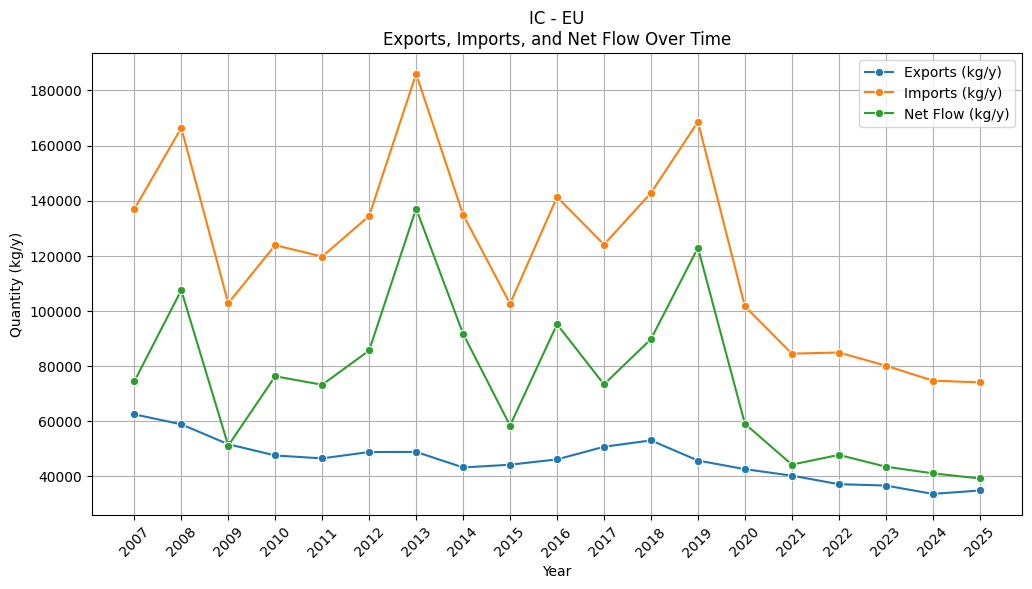

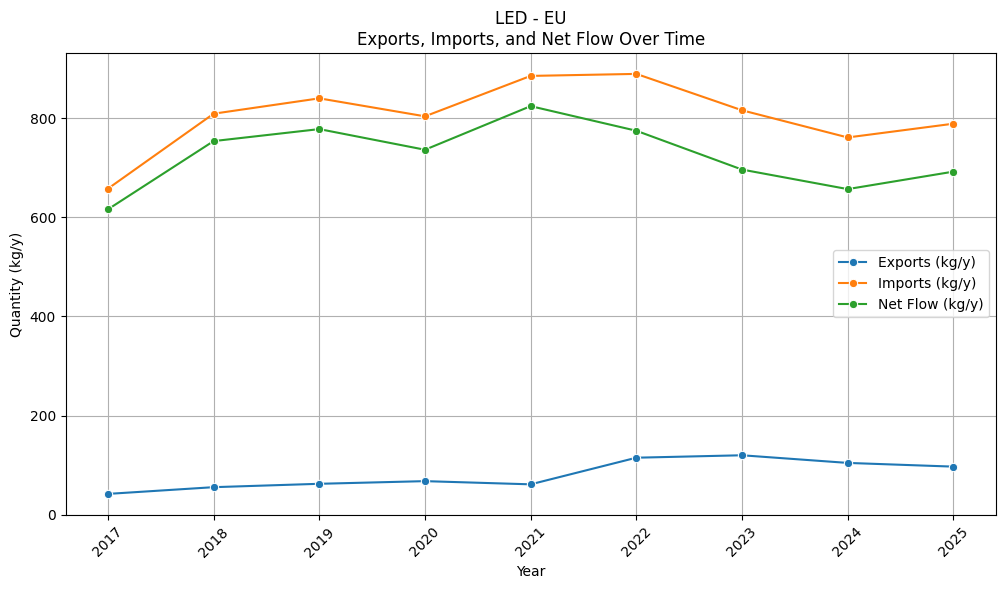

Product = IC...


FLOW,TIME_PERIOD,Exports_kg,Imports_kg,Net_Flow_kg
0,2007,62489.6300,136919.8950,74430.2650
1,2008,58879.1875,166409.2500,107530.0625
2,2009,51647.8795,102788.2380,51140.3585
3,2010,47567.2680,123867.5165,76300.2485
4,2011,46506.7505,119721.4095,73214.6590
5,2012,48816.3025,134469.8075,85653.5050
6,2013,48860.5740,185997.4585,137136.8845
7,2014,43213.5725,134937.5370,91723.9645
8,2015,44215.3460,102617.2070,58401.8610
9,2016,46142.4320,141304.4500,95162.0180


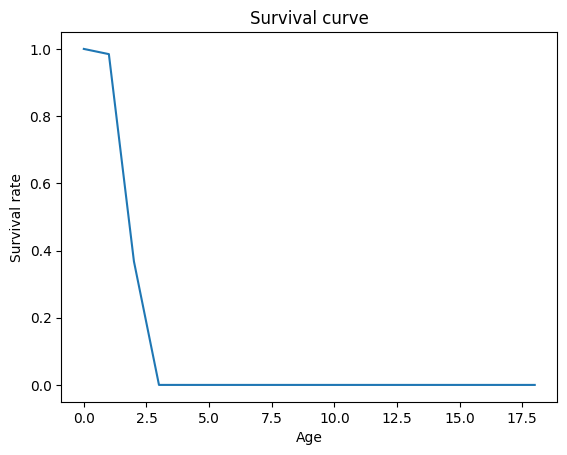

year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
year,,,,,,,,,,,,,,,,,,,
2007,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2008,0.984,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2009,0.368,0.984,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2010,0.000,0.368,0.984,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2011,0.000,0.000,0.368,0.984,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2012,0.000,0.000,0.000,0.368,0.984,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2013,0.000,0.000,0.000,0.000,0.368,0.984,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2014,0.000,0.000,0.000,0.000,0.000,0.368,0.984,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2015,0.000,0.000,0.000,0.000,0.000,0.000,0.368,0.984,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0


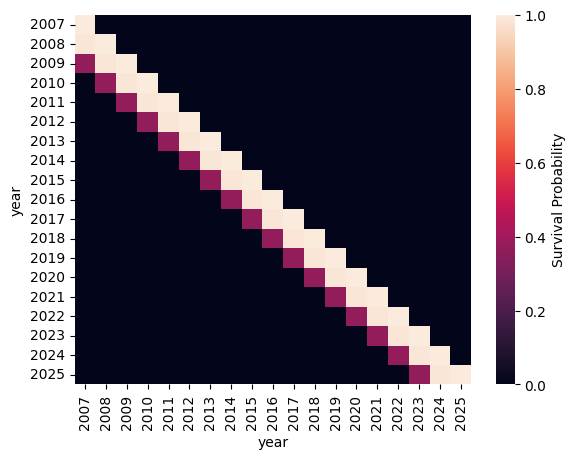

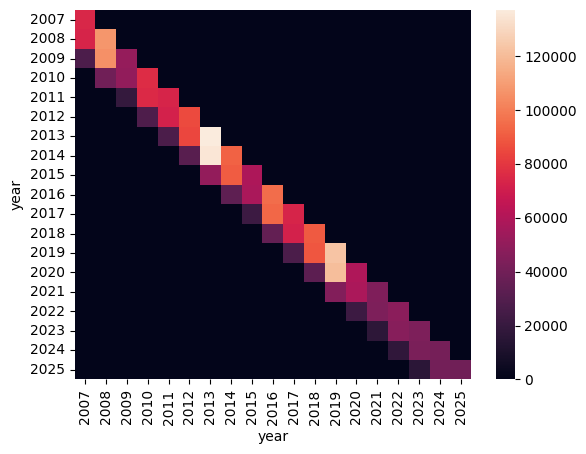

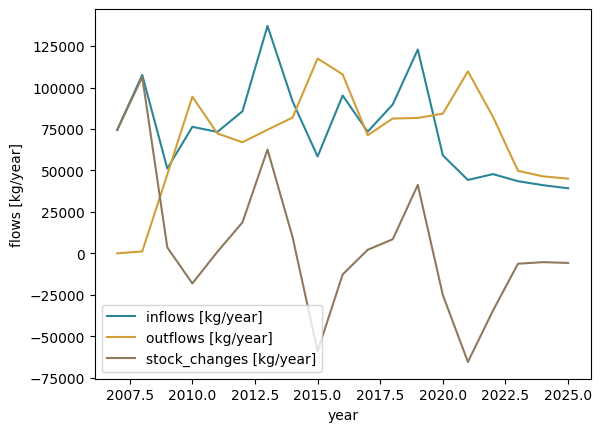

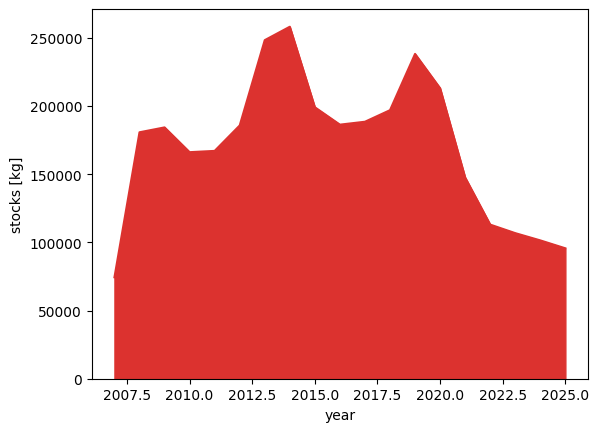

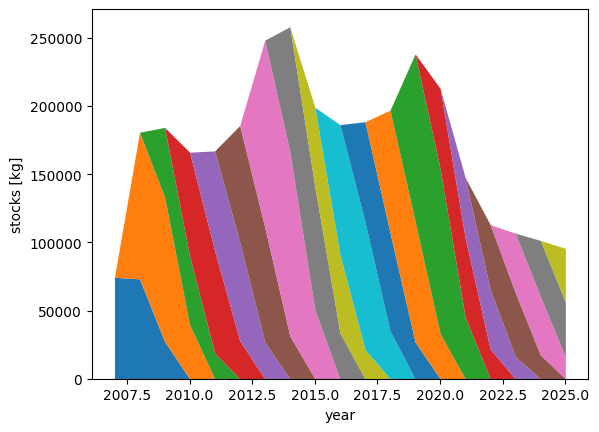

Product (MFA system) = IC...


,stocks [kg]
year,
2007,74430.265000
2008,180806.393198
2009,184384.686197
2010,166206.689664
2011,167146.683488
2012,185802.946635
2013,248397.485092
2014,258245.729620
2015,199154.585637


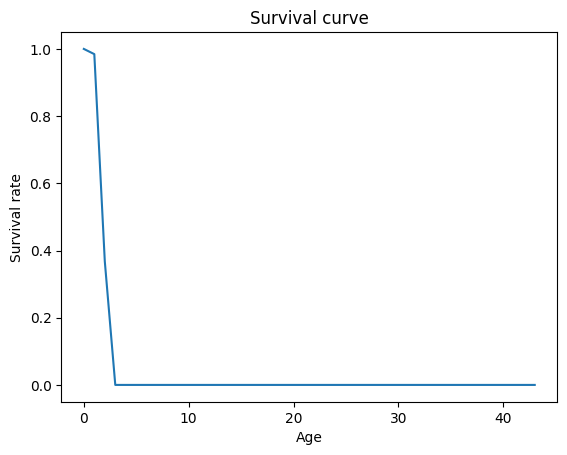

year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
year,,,,,,,,,,,,,,,,,,,,,
2007,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2008,0.984,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2009,0.368,0.984,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2010,0.000,0.368,0.984,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2011,0.000,0.000,0.368,0.984,1.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2012,0.000,0.000,0.000,0.368,0.984,1.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2013,0.000,0.000,0.000,0.000,0.368,0.984,1.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2014,0.000,0.000,0.000,0.000,0.000,0.368,0.984,1.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2015,0.000,0.000,0.000,0.000,0.000,0.000,0.368,0.984,1.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0


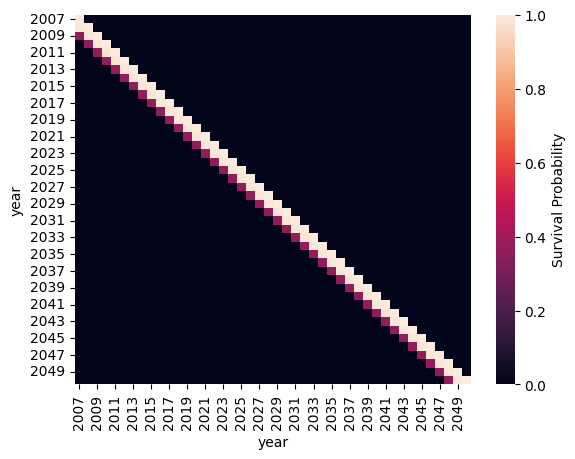

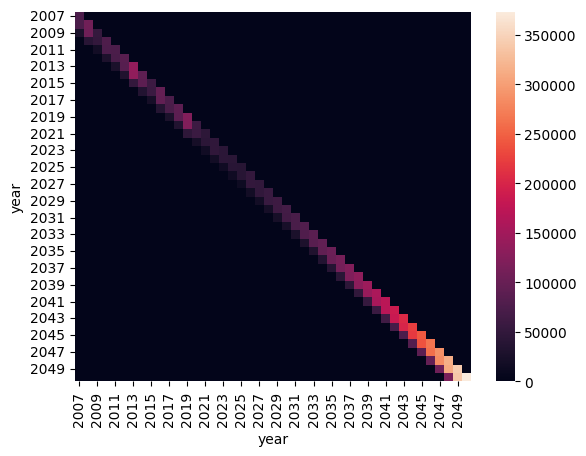

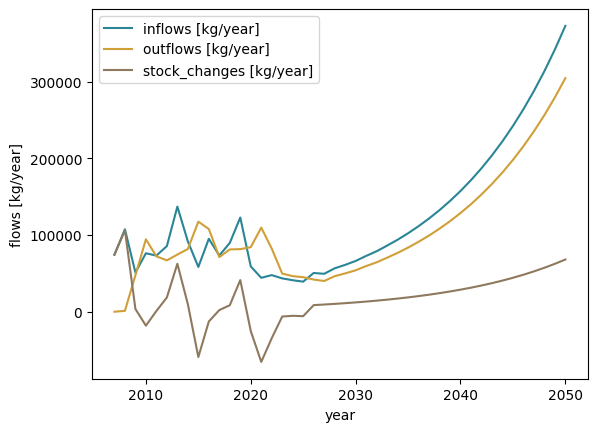

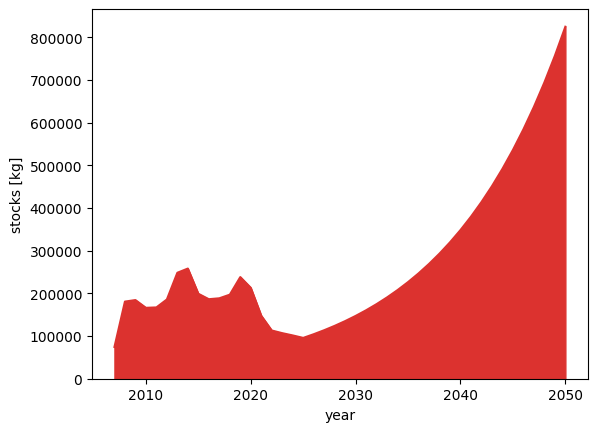

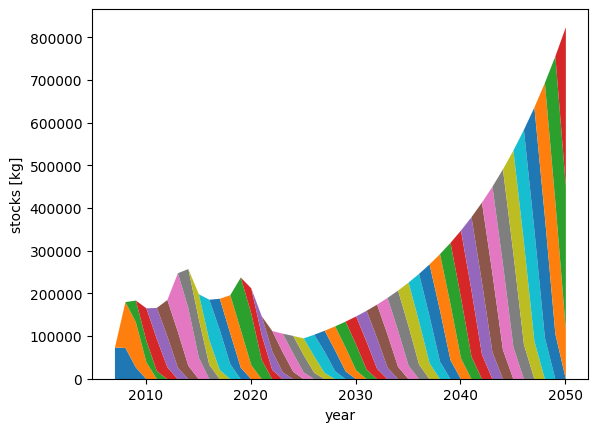

Product = LED...


FLOW,TIME_PERIOD,Exports_kg,Imports_kg,Net_Flow_kg
0,2017,41.723192,658.028196,616.305004
1,2018,55.302492,809.432974,754.130482
2,2019,62.118644,840.460614,778.341970
3,2020,67.479748,804.130474,736.650726
4,2021,61.035422,885.752154,824.716732
5,2022,114.809674,889.816382,775.006708
6,2023,119.718396,816.344900,696.626504
7,2024,104.286098,761.457536,657.171438
8,2025,96.785136,789.241796,692.456660


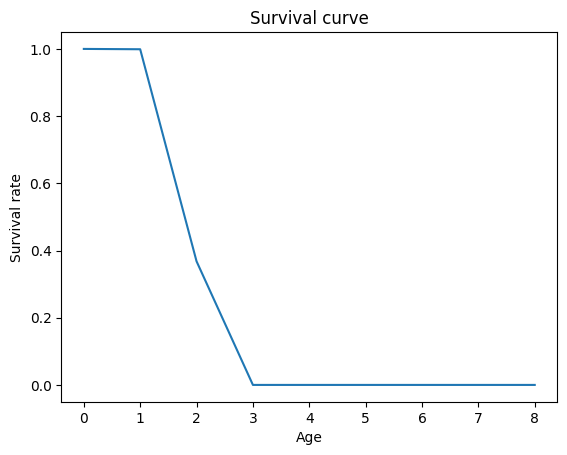

year,2017,2018,2019,2020,2021,2022,2023,2024,2025
year,,,,,,,,,
2017,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2018,0.999,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2019,0.368,0.999,1.000,0.000,0.000,0.000,0.000,0.000,0.0
2020,0.000,0.368,0.999,1.000,0.000,0.000,0.000,0.000,0.0
2021,0.000,0.000,0.368,0.999,1.000,0.000,0.000,0.000,0.0
2022,0.000,0.000,0.000,0.368,0.999,1.000,0.000,0.000,0.0
2023,0.000,0.000,0.000,0.000,0.368,0.999,1.000,0.000,0.0
2024,0.000,0.000,0.000,0.000,0.000,0.368,0.999,1.000,0.0
2025,0.000,0.000,0.000,0.000,0.000,0.000,0.368,0.999,1.0


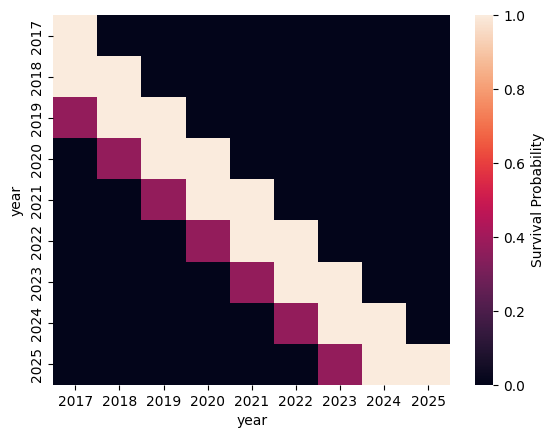

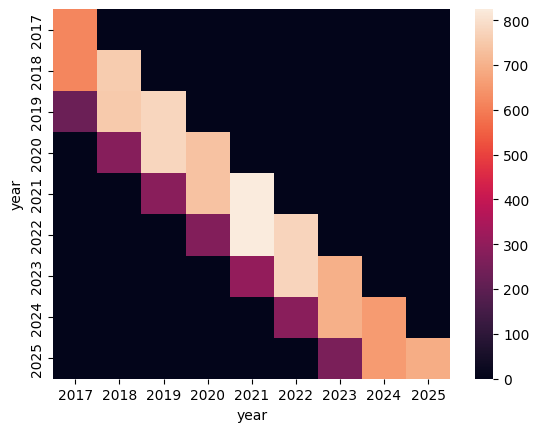

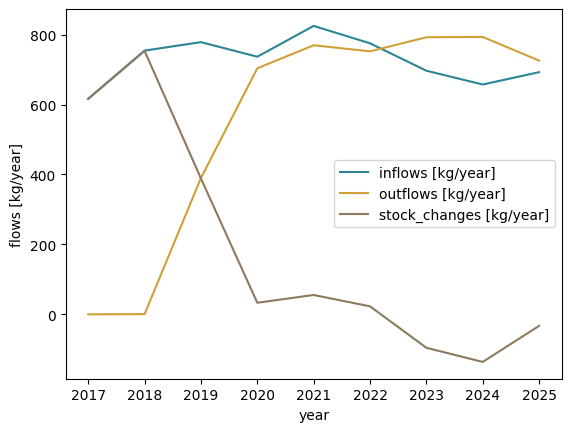

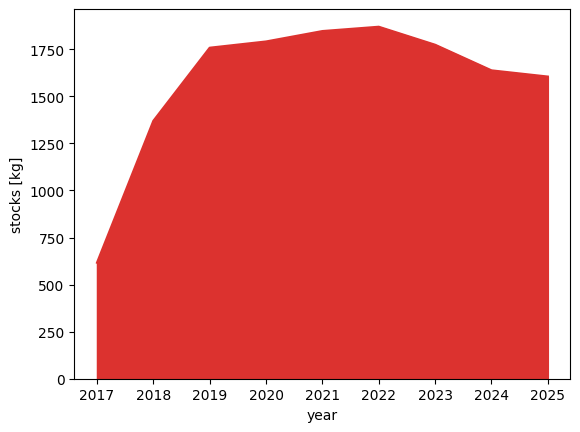

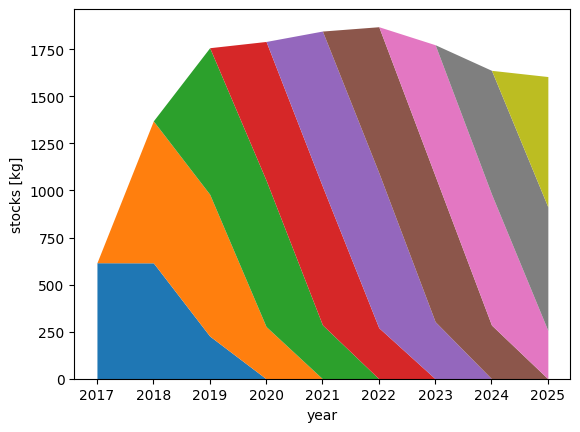

Product (MFA system) = LED...


,stocks [kg]
year,
2017,616.305004
2018,1369.833919
2019,1758.462296
2020,1791.662068
2021,1846.984433
2022,1869.917103
2023,1774.273069
2024,1638.227009
2025,1605.261211


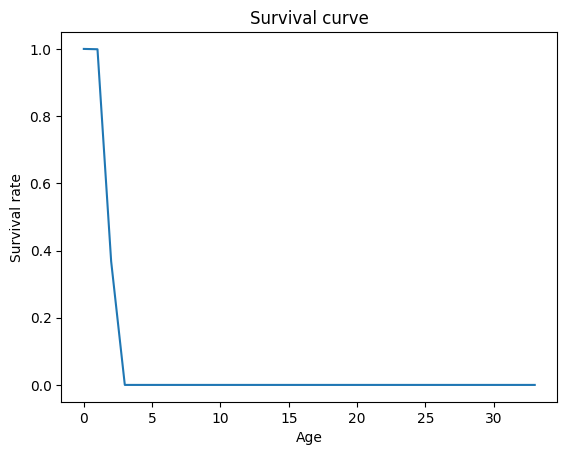

year,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
year,,,,,,,,,,,,,,,,,,,,,
2017,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2018,0.999,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2019,0.368,0.999,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2020,0.000,0.368,0.999,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2021,0.000,0.000,0.368,0.999,1.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2022,0.000,0.000,0.000,0.368,0.999,1.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2023,0.000,0.000,0.000,0.000,0.368,0.999,1.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2024,0.000,0.000,0.000,0.000,0.000,0.368,0.999,1.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
2025,0.000,0.000,0.000,0.000,0.000,0.000,0.368,0.999,1.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0


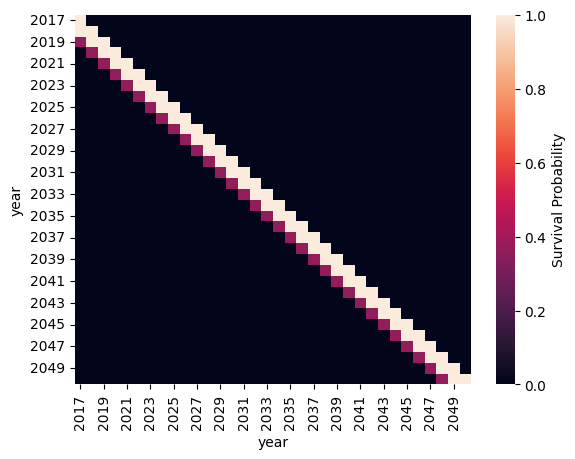

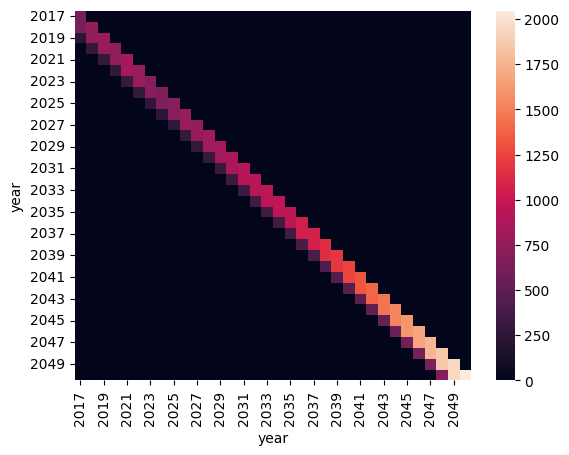

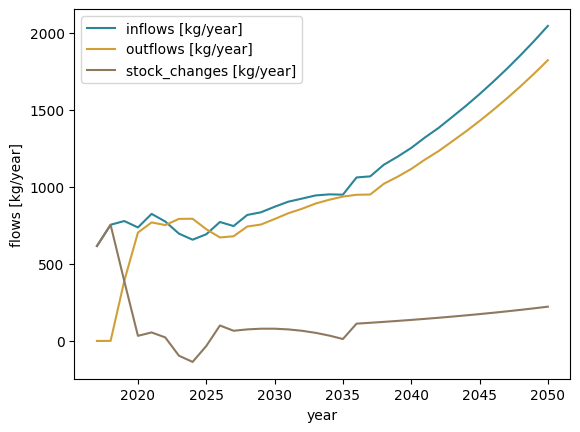

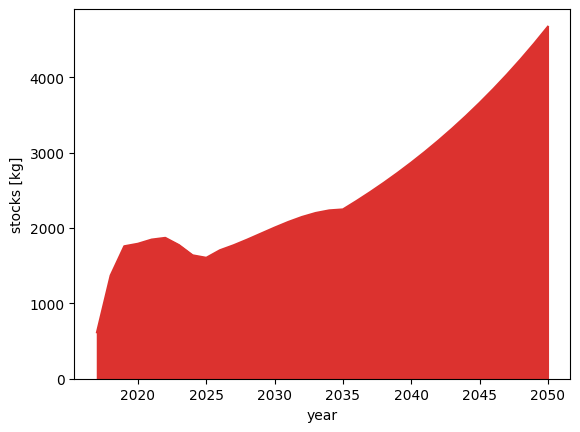

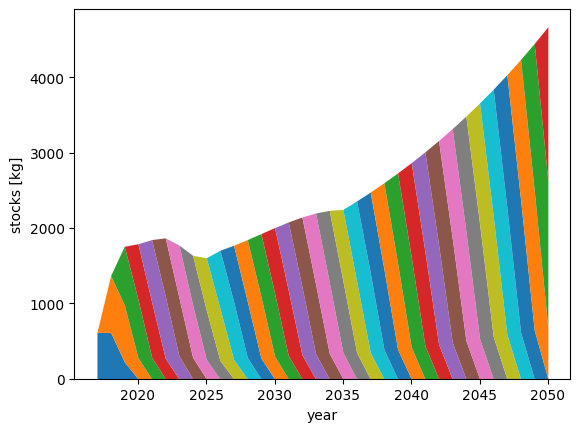

,year,stage_number,stage_name,flow_type,target_stage_number,target_stage_name,value_kg,product
0,2007,1,Mining,inflow,NaN,NaN,0.000000,IC
1,2008,1,Mining,inflow,NaN,NaN,0.000000,IC
2,2009,1,Mining,inflow,NaN,NaN,0.000000,IC
3,2010,1,Mining,inflow,NaN,NaN,0.000000,IC
4,2011,1,Mining,inflow,NaN,NaN,0.000000,IC
...,...,...,...,...,...,...,...,...
2413,2046,8,End-of-Life,outflow_waste,NaN,NaN,1499.216561,LED
2414,2047,8,End-of-Life,outflow_waste,NaN,NaN,1573.874142,LED
2415,2048,8,End-of-Life,outflow_waste,NaN,NaN,1652.741520,LED
2416,2049,8,End-of-Life,outflow_waste,NaN,NaN,1735.316653,LED


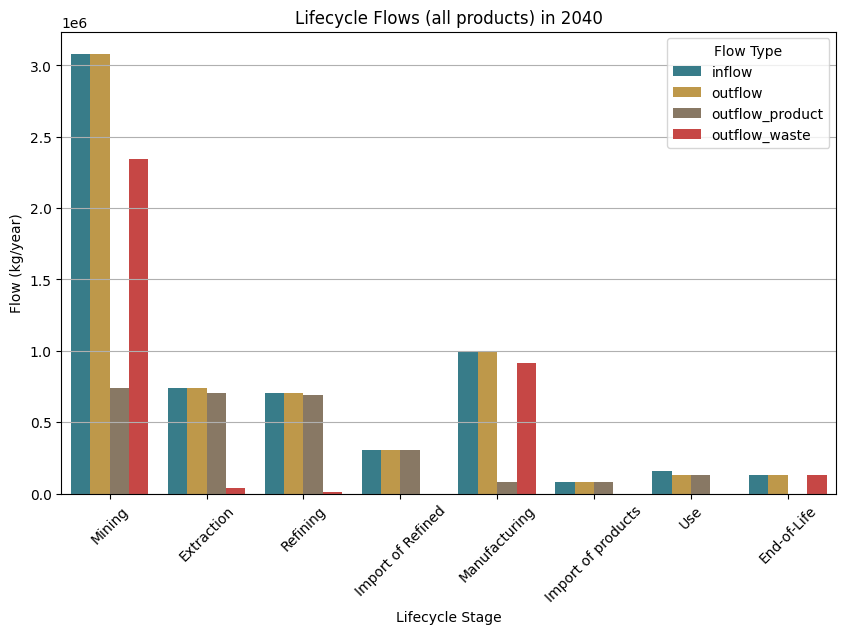

In [60]:
import copy

# Scenario parameter 1: fraction of Manufacturing's inflow that is imported refined gallium.
# From EU CRMA: EU should have 40% of processing and not rely on one country for one material for more than 65%.
# It is assumed that the percentage growth per year between 2030 and 2050 is less, but leading to a doubling
# of the current 2030 ambition.
# Source: (European Commission, 2023)
raw_import_year_percentage_dict = {
    2025: 1 - 0.0,
    2030: 1 - 0.4,
    2050: 1 - 0.8,
}
raw_import_fraction = {
    "IC": import_scenario_calculation(raw_import_year_percentage_dict),
    "LED": import_scenario_calculation(raw_import_year_percentage_dict),
}

# Scenario parameter 2: fraction of Use's inflow that is imported finished products, per product.
# From EU Chips Act. Increase from approxamitely 10% of world production to 20% by 2030.
# This is assumed to lead to a 50% import fraction of the EU's IC use-phase stock by 2030.
# For LED, the same assumption is made.
# Source: (European Court of Auditors., 2025)
product_import_fraction_dict = {
    2025: 1 - 0.0,
    2030: 1 - 0.5,
    2050: 1 - 0.5,
}
product_import_fraction = {
    "IC": import_scenario_calculation(product_import_fraction_dict),
    "LED": import_scenario_calculation(product_import_fraction_dict),
}

# Scenario parameter 3: future development of each product's use-phase stock.
bau_stock_scenario = {
    # BAU projection for IC, expected to grow by approximately 9% per year to reach a doubling between 2022 and 2030
    # Source: (European Commission, n.d.)
    "IC": {
        "type": "exponential",
        "yearly_growth_rate": 0.09,
        "end_year": 2050,
    },
    # BAU projection for LED, expected to increase from 50% in 2023 to 90% in 2035, then continue to grow at 5% per year until 2050
    # Source: (IEA, 2023) and (European Commission. Joint Research Centre., 2023)
    "LED": {
        "type": "s-curve",
        "start_year": 2023,
        "saturation_year": 2035,
        "end_year": 2050,
        "start_share": 0.5,
        "end_share": 0.9,
        "continued_yearly_growth_rate": 0.05,  # 50% of current growth without saturation. Source: (European Commission. Joint Research Centre., 2023)
    },
}
# copy an independent scenario for the high-demand case, then adjust the growth parameters
high_demand_stock_scenario = copy.deepcopy(bau_stock_scenario)
high_demand_stock_scenario["IC"]["yearly_growth_rate"] = 0.12  # Scenario 150% of BAU
high_demand_stock_scenario["LED"]["continued_yearly_growth_rate"] = (
    0.10  # Scenario 200% of BAU => 100% of current growth without saturation. Source: (European Commission. Joint Research Centre., 2023)
)


# Run the main MFA with the specified scenario parameters
lifecycle_flows_df = run_main_MFA(
    eurostat_df=eurostat_df,
    product_info=product_info,
    use_phase_stage_number=use_phase_stage_number,
    detailed_plot=True,
    scenario_1_raw_import_fraction=raw_import_fraction,
    scenario_2_product_import_override=product_import_fraction,
    scenario_3_stock_scenario=bau_stock_scenario,
)

# Specify year to plot
year_to_plot = 2040

# Bar plot for the specified year (aggregated across product categories)
lifecycle_flows_agg = combine_lifecycle_flows(lifecycle_flows_df)
plot_lifecycle_flows_barplot(
    lifecycle_flows_agg[lifecycle_flows_agg["year"] == year_to_plot],
    year=year_to_plot,
)

# Sankey: shared upstream and End-of-Life, split only at the Use stage
plot_sankey_lifecycle_flows(
    lifecycle_flows_df,
    year=year_to_plot,
    split_stage=use_phase_stage_number,
    plot_waste_per_stage=True,
)

## Main run scenarios
This section defines a dictionary with the different scenarios using the information setup in `## Scenario setup and initial model run`

In [61]:
MFA_scenarios = {
    "BAU": {
        "name": "Business-as-usual",
        "narrative_name": "Status Quo",
        "raw_import_fraction": 1,
        "product_import_fraction": 1,
        "bau_stock_scenario": bau_stock_scenario,
    },
    "High Demand": {
        "name": "EU DD success",
        "narrative_name": "The Chip Race",
        "raw_import_fraction": 1,
        "product_import_fraction": 1,
        "bau_stock_scenario": high_demand_stock_scenario,
    },
    "High Supply": {
        "name": "EU CRM success",
        "narrative_name": "Made in EU",
        "raw_import_fraction": raw_import_fraction,
        "product_import_fraction": product_import_fraction,
        "bau_stock_scenario": bau_stock_scenario,
    },
    "High Demand + High Supply": {
        "name": "EU DD + CRM success",
        "narrative_name": "Chip Race, Made in EU",
        "raw_import_fraction": raw_import_fraction,
        "product_import_fraction": product_import_fraction,
        "bau_stock_scenario": high_demand_stock_scenario,
    },
}

scenario_results = {}

for scenario_key, scenario_params in MFA_scenarios.items():
    print(f"Running scenario: {scenario_params['name']} ({scenario_key})")
    scenario_details = run_main_MFA(
        eurostat_df=eurostat_df,
        product_info=product_info,
        use_phase_stage_number=use_phase_stage_number,
        detailed_plot=False,
        scenario_1_raw_import_fraction=scenario_params["raw_import_fraction"],
        scenario_2_product_import_override=scenario_params["product_import_fraction"],
        scenario_3_stock_scenario=scenario_params["bau_stock_scenario"],
        return_details=True,
    )
    scenario_results[scenario_key] = scenario_details
    lifecycle_flows_df = scenario_details["lifecycle_flows_df"]

    # Bar plot for the specified year (aggregated across product categories)
    # lifecycle_flows_agg = combine_lifecycle_flows(lifecycle_flows_df)
    # plot_lifecycle_flows_barplot(
    #     lifecycle_flows_agg[lifecycle_flows_agg["year"] == year_to_plot],
    #     year=year_to_plot,
    # )

    # Sankey: shared upstream and End-of-Life, split only at the Use stage
    plot_sankey_lifecycle_flows(
        lifecycle_flows_df,
        year=2030,
        split_stage=use_phase_stage_number,
        plot_waste_per_stage=False,
        save_plot_path=f"plots/sankey_{scenario_key}_2030.png",
        scale=6,
        width=600,
        height=400,
        show_end_values=True,
    )

    plot_sankey_lifecycle_flows(
        lifecycle_flows_df,
        year=2050,
        split_stage=use_phase_stage_number,
        plot_waste_per_stage=False,
        save_plot_path=f"plots/sankey_{scenario_key}_2050.png",
        scale=6,
        width=600,
        height=400,
        show_end_values=True,
    )

Running scenario: Business-as-usual (BAU)


Running scenario: EU DD success (High Demand)


Running scenario: EU CRM success (High Supply)


Running scenario: EU DD + CRM success (High Demand + High Supply)


## Main run sensitivity
In order to analyse the sensitivity of the model to the differnet model inputs, we focus on 3 specific gallium flows, that are crucial for the research question:

- Total domestic mining
- Imported refined material
- Import of products.

We investigate them at two points in time:

- 2030 => The final year of the two most important EU policies (CRMA and Digital Decade, with the Chips Act)
- 2050 => End of the modelling time-flow

The following inputs are varied one by one +10%/-10%, while holding the other constant:

- Net import of products
- Each TC upstream of use-phase
- Each product information: market share, material intensity, and survival-curve parameters

The results will be shown in a heatmap compared to the 0% varied scenario (BAU).

**Process:**

1. Build a dictionary with all the sensitivity parameters
2. Run the sensitivity analysis for one scenario
3. Plot the sensitivity anslysis (heatmaps)
4. Redo step 2. and 3. for each scenario (defined in the earlier section)

**Results:**

Looking at the BAU scenario it is of course only the imported products that can be affected by the sensitivity analysis, as there is no domestic production (of the products that were previously imported). 

Accross all scenarios the net import variation scales directly the output, which makes sense as it is the primary input on which everything else is scaled.

For all scenarios it is also clear, that since ICs dominate the two product groups, it is also the IC product parameters (material intensity and market share) that have the highest sensitivity. For the high demand scenarios and for 2050 the survival parameters also starts to play a larger role. But LED parameters have negligible impact, probably due to their low share of the total.

Some of the TCs have an opposite sign impact, as increasing the product TC actually decreases the waste and thereby decreases the needed flow from the step earlier. For example TC manufacturing->Use, where if it increases it has an opposite sign impact on the mining needed, since less is waste.

Some of the TCs also have a higher impact than 10% on the output, this is probably due to the propagated change.

It should be noted, that some of the +10% changes are 0.0, since the original value was already 1.0.

Generally this underlines that the most important for sensitivity is the product information of the ICs and the TCs.

Sensitivity sweep: Business-as-usual (BAU)


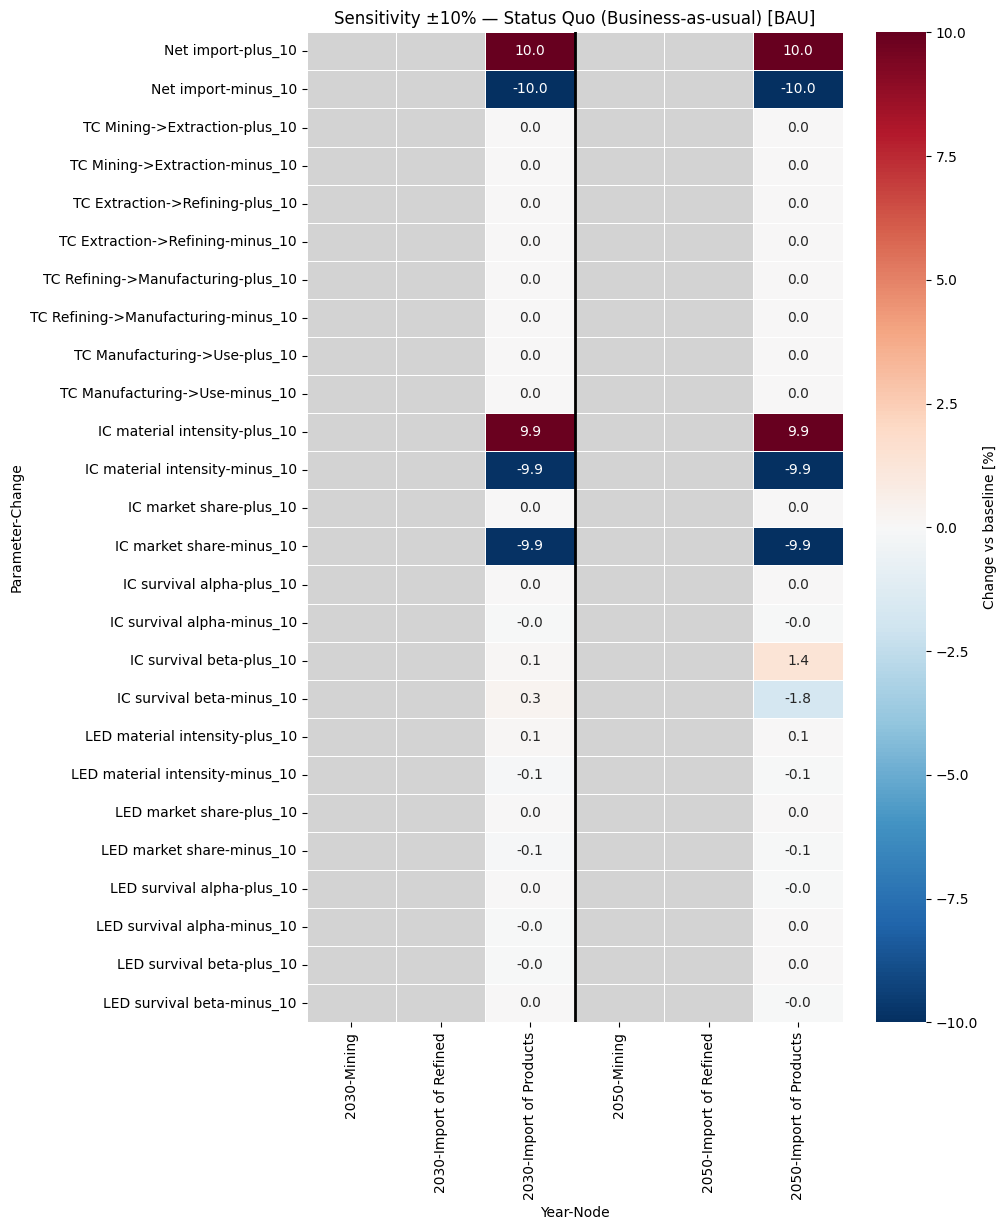

Sensitivity sweep: EU DD success (High Demand)


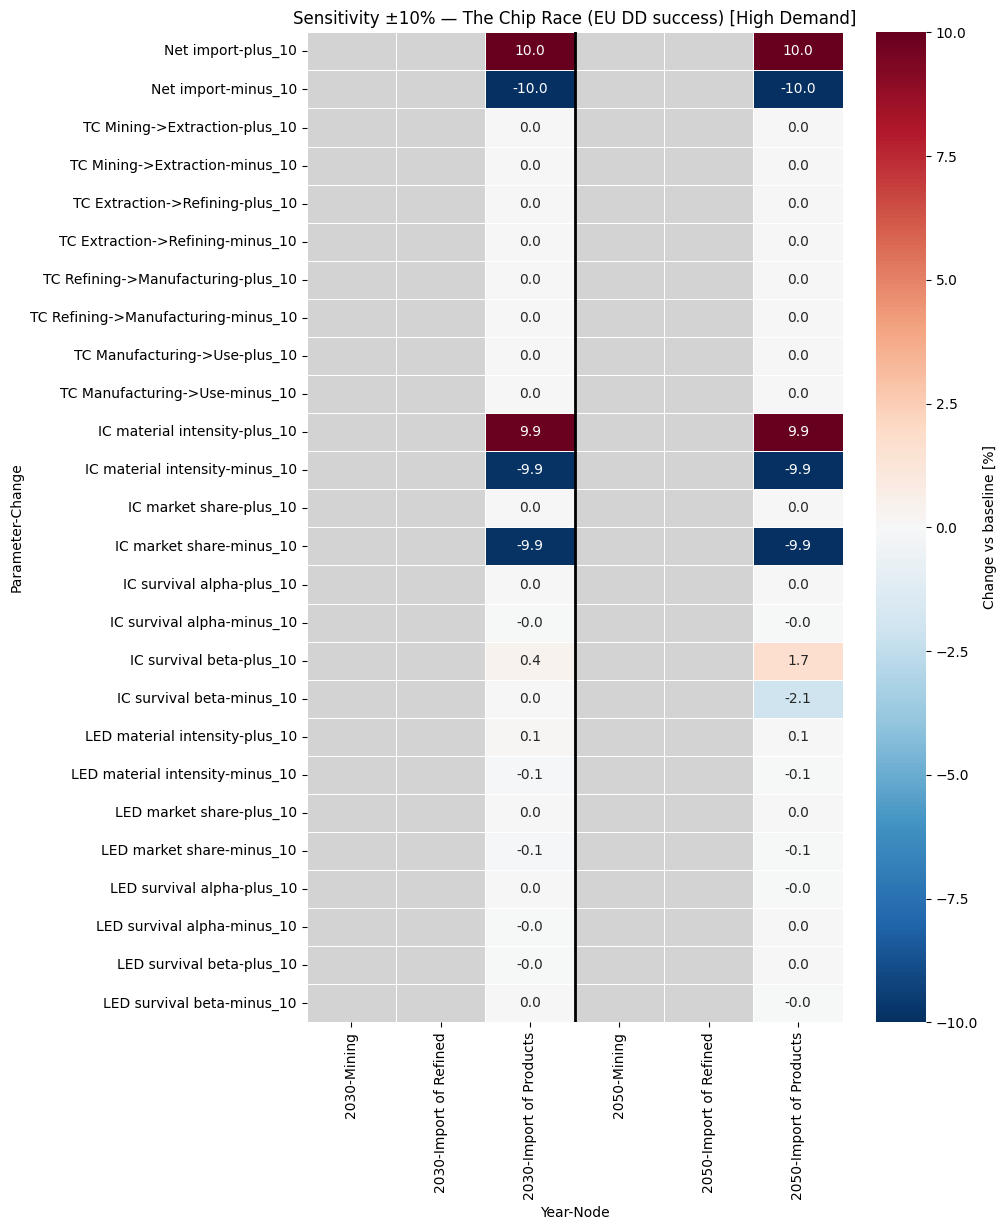

Sensitivity sweep: EU CRM success (High Supply)


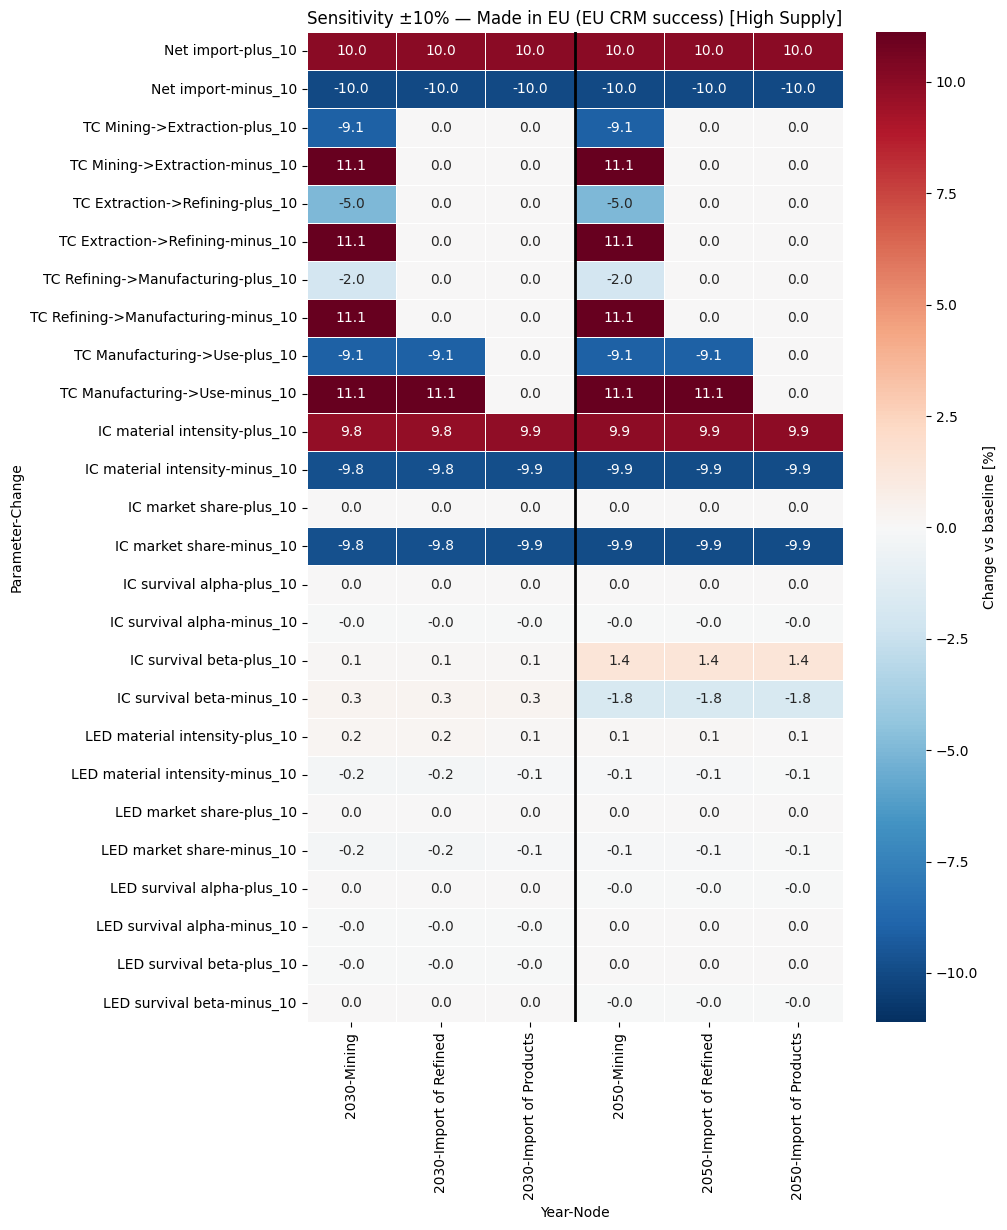

Sensitivity sweep: EU DD + CRM success (High Demand + High Supply)


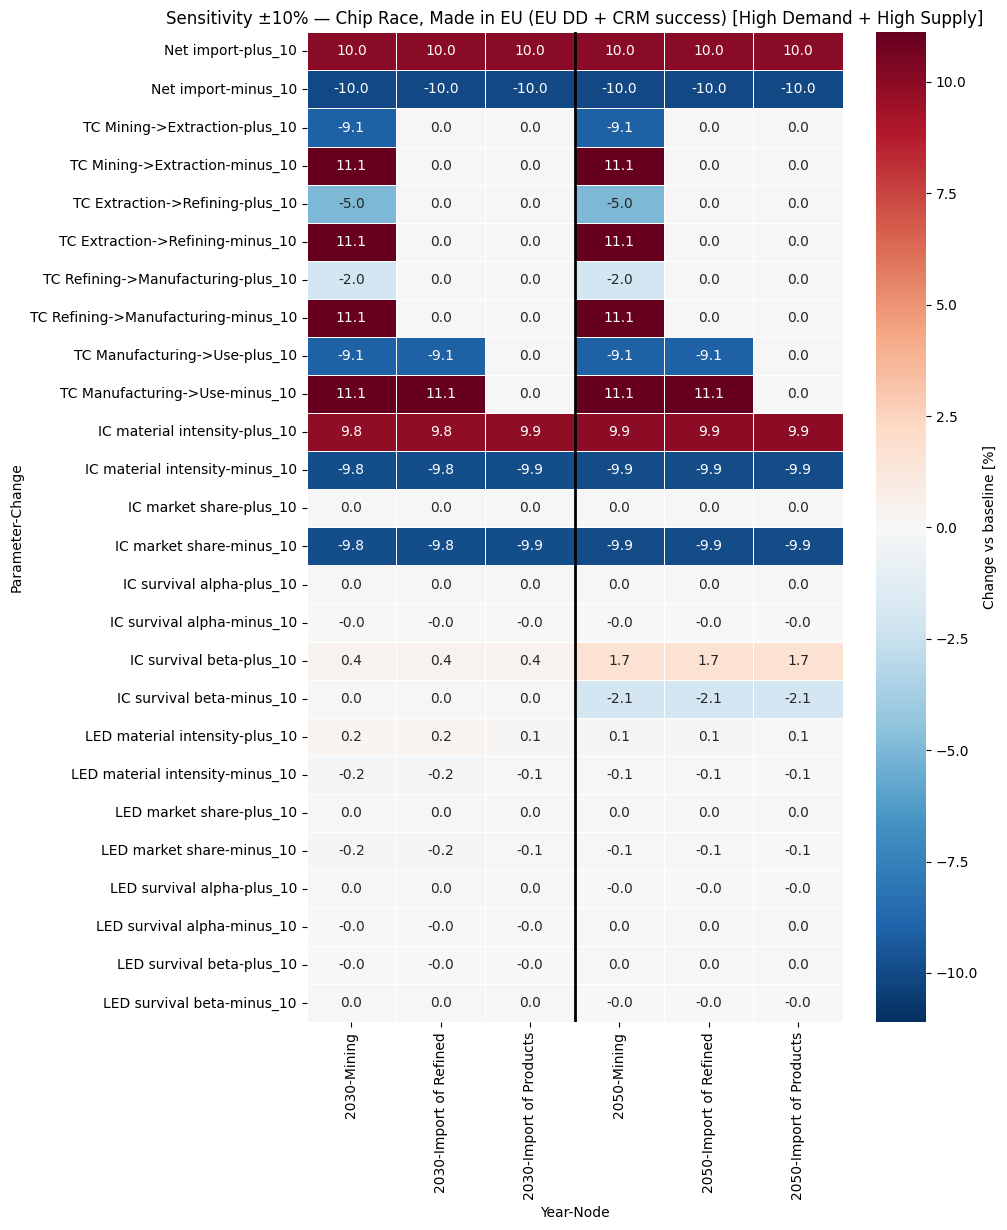

In [62]:
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Years to investigate for the sensitivity analysis
years_to_investigate = [2030, 2050]

# Nodes investigated for output (stage_number -> display name).
output_nodes_flow = {
    1: "Mining",
    4: "Import of Refined",
    6: "Import of Products",
}

# Perturbation directions: relative change applied one-at-a-time to each parameter.
plus_minus = {"plus_10": 0.10, "minus_10": -0.10}


##############################################################################
### 1 ### Dictionary of sensitivity parameters
def build_sensitivity_parameters():
    """Builds a dictionary with all the sensitivity parameters.

    Each spec is plain data with a "type", specifying what run_scenarios should do:
      - "obs"     : the Eurostat imp/exp table (net import).
      - "tc"      : a transfer coefficient in every product.
      - "product" : a per-product value.
    Edges 4->5 and 6->7 are structural import pass-throughs (=1.0) and are excluded from TC sensitivity.

    Returns:
        dict: {label: spec} describing each parameter to vary.
    """
    parameters = {
        "Net import": {"kind": "obs"},
        "TC Mining->Extraction": {"kind": "tc", "edge": (1, 2)},
        "TC Extraction->Refining": {"kind": "tc", "edge": (2, 3)},
        "TC Refining->Manufacturing": {"kind": "tc", "edge": (3, 5)},
        "TC Manufacturing->Use": {"kind": "tc", "edge": (5, 7)},
    }
    product_specific_parameter_fields = {
        "material intensity": ["material_intensity_Ga"],
        "market share": ["market_share"],
        "survival alpha": ["survival_curve_parameters", "alpha"],
        "survival beta": ["survival_curve_parameters", "beta"],
    }

    # For each product, add the product-specific parameters to the sensitivity "parameters" dictionary.
    for prod in product_info:  # IC, LED
        for label, keys in product_specific_parameter_fields.items():
            parameters[f"{prod} {label}"] = {
                "kind": "product",
                "product": prod,
                "keys": keys,
            }
    return parameters


##############################################################################
### 2 ### Run the sensitivity sweep for ONE scenario
def run_sensitivity(scenario_params, parameters):
    """Run a +-10% one-at-a-time sweep for a single scenario.

    Args:
        scenario_params: Dictionary of scenario parameters
            (raw import fraction, product import fraction, stock scenario).
            Created by MFA_scenarios.
        parameters: Dictionary of sensitivity parameters to vary.
            Created by build_sensitivity_parameters().

    Returns:
        A pd.DataFrame with relative change in Ga inflow vs the BAU scenario [%].
            Rows = (parameter, change)
            columns = (year, node).
            NaN where the baseline flow is 0 (e.g., Mining when raw_import_fraction == 1).
    """

    def _run_MFA_isolate_output(eurostat_in, product_info_in):
        """Run the MFA and return the isolated output for the sensitivity analysis.

        Args:
            eurostat_in: Eurostat imp/exp table data (possibly perturbed).
            product_info_in: Product info dictionary (possibly perturbed).

        Returns:
            dict: {(year, node): total inflow kg} at the output nodes.
        """
        lf = run_main_MFA(
            eurostat_df=eurostat_in,
            product_info=product_info_in,
            use_phase_stage_number=use_phase_stage_number,
            detailed_plot=False,
            scenario_1_raw_import_fraction=scenario_params["raw_import_fraction"],
            scenario_2_product_import_override=scenario_params[
                "product_import_fraction"
            ],
            scenario_3_stock_scenario=scenario_params["bau_stock_scenario"],
        )
        lf = lf[
            (lf["flow_type"] == "inflow") & lf["stage_number"].isin(output_nodes_flow)
        ]
        totals = lf.groupby(["year", "stage_number"])["value_kg"].sum()
        return {
            (year, node): float(totals.get((year, node), 0.0))
            for year in years_to_investigate
            for node in output_nodes_flow
        }

    def _scale_specification(specification, f):
        """Return (eurostat_df, product_info) deep copies with the parameter scaled by f.

        Args:
            spec: Dictionary describing the parameter to vary (from parameters).
            f: Scaling factor (e.g., 1.10 for +10%, 0.90 for -10%).

        Returns:
            Tuple of (eurostat_df, product_info) with the specified parameter scaled.
        """
        # Create a deep copy of the eurostat_df and product_info to avoid modifying the originals
        eu = (
            eurostat_df.copy()
        )  # not deepcopy because it is only a Dataframe vary not a nested structure
        product_information = copy.deepcopy(product_info)

        # Apply the perturbation based on the kind of parameter specified
        if specification["kind"] == "obs":
            # Scale the OBS_VALUE directly
            eu["OBS_VALUE"] *= f
        elif specification["kind"] == "tc":
            # Extract source and destination from the edge specification
            source, destination = specification["edge"]

            # For each product, scale the transfer coefficient for the specified edge
            for product in product_information:
                # Access the transfer coefficient for the specified edge
                tc = product_information[product]["lifecycle_stages"][source][
                    "TC_output"
                ]

                # Scale the transfer coefficient for the specified destination
                if destination in tc:
                    tc[destination] *= f
                    # Must not exceed 1.0, as it is a fraction of the stage output
                    tc[destination] = min(tc[destination], 1.0)
        elif specification["kind"] == "product":
            # Extract the product and keys from the specification
            node = product_information[specification["product"]]

            # Navigate through the nested keys to reach the target parameter
            for key in specification["keys"][:-1]:
                node = node[key]

            # Scale the target parameter by f
            node[specification["keys"][-1]] *= f

            # if key is "material_intensity_Ga", ensure it does not go below 0
            if specification["keys"][-1] == "material_intensity_Ga":
                node[specification["keys"][-1]] = max(
                    node[specification["keys"][-1]], 0.0
                )

            # if key is "market_share", ensure it does not exceed 1.0
            if specification["keys"][-1] == "market_share":
                node[specification["keys"][-1]] = min(
                    node[specification["keys"][-1]], 1.0
                )

        # Return the modified copies of eurostat_df and product_info
        return eu, product_information

    # Isolate the baseline output for the scenario (without perturbation)
    base = _run_MFA_isolate_output(eurostat_df, copy.deepcopy(product_info))

    # Initialize a dictionary to hold the results of the sensitivity analysis
    parameter_result = {}
    # For each parameter
    for label, spec in parameters.items():
        # For direction in plus_minus (+10% and -10%)
        for direction, pct in plus_minus.items():
            # Run the MFA with the parameter perturbed by the specified percentage
            varied = _run_MFA_isolate_output(*_scale_specification(spec, 1 + pct))

            # Calculate the relative change vs baseline for each output node and year
            parameter_result[(label, direction)] = {
                col: (varied[col] - base[col]) / base[col] * 100
                if base[col]
                else np.nan
                for col in base
            }

    # Transpose and save the result in a dataframe
    result = pd.DataFrame(parameter_result).T
    # Set the index and columns to MultiIndex for better organization
    # Example: IC material intensity-plus_10 => ("IC material intensity", "plus_10")
    result.index = pd.MultiIndex.from_tuples(
        result.index, names=["Parameter", "Change"]
    )
    # Set the columns to MultiIndex with year and node names for clarity
    # Results in 6 columns:
    # (2030, Mining), (2030, Import of Refined), (2030, Import of Products),
    # (2050, Mining), (2050, Import of Refined), (2050, Import of Products)
    result.columns = pd.MultiIndex.from_tuples(
        [(year, output_nodes_flow[node]) for year, node in result.columns],
        names=["Year", "Node"],
    )
    return result


##############################################################################
### 3 ### Plot one scenario's result as a heatmap
def plot_sensitivity(result, title, save_path=None):
    """Heatmap of relative change [%]; columns are the output nodes grouped by year.

    Args:
        result: DataFrame with relative change [%] for each parameter and year/node.
            Created by run_sensitivity().
        title: Title for the heatmap.
        save_path: Optional path to save the heatmap image (PNG).
    """
    vmax = np.nanmax(np.abs(result.values)) or 1.0  # Avoid vmax=0
    fig, ax = plt.subplots(figsize=(10, 0.4 * len(result) + 2))
    sns.heatmap(
        result,
        cmap="RdBu_r",  # Color to show positive and negative changes difference
        center=0,
        vmin=-vmax,
        vmax=vmax,
        annot=True,
        fmt=".1f",
        linewidths=0.5,
        linecolor="white",
        mask=result.isna(),
        cbar_kws={"label": "Change vs baseline [%]"},
        ax=ax,
    )
    ax.set_facecolor("lightgrey")  # masked (undefined) cells show through as grey
    # Separator between the two year groups on the x-axis.
    ax.axvline(len(output_nodes_flow), color="black", lw=2)
    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


##############################################################################
### 4 ### Run + plot, one scenario at a time
# Build the sensitivity parameters dictionary
sensitivity_parameters = build_sensitivity_parameters()

# For each scenario, run the sensitivity sweep and plot the results
sensitivity_analysis_results = {}
for scenario_key, scenario_params in MFA_scenarios.items():
    print(f"Sensitivity sweep: {scenario_params['name']} ({scenario_key})")
    # Run sensitivity analysis
    result = run_sensitivity(scenario_params, sensitivity_parameters)
    # Save results
    sensitivity_analysis_results[scenario_key] = result
    # Plot the sensitivity heatmap
    plot_sensitivity(
        result,
        title=f"Sensitivity ±10% — {scenario_params['narrative_name']} ({scenario_params['name']}) [{scenario_key}]",
        save_path=f"plots/sensitivity_{scenario_key}.png",
    )


## Validation of results
For estimating materials in electronics and especially for bottom-up, it is always difficult to find the right sources and they often do not agree. I have based my 

Comparing my stock and net import numbers for the historical data to studies I can at least see, that I'm within reasonable range of the flow to in-use products. 

- Han et al. (2024) = For average of 2024 global inflow to use phase LEDs and ICs is approximately 4700 ton / year
- Gao et al. (2024) = For average of 2000-2020 global inflow to use phase LEDs and ICs is approximately 2900 ton / year
- SCRREEN2 (2020) = For average of 2016-2020 the global **production** is approximately 301 ton / year (EU consumes 10%)
- This study = Import (to EU) inflow to use phase LEDs and ICs is for 2024 is approximately 41 ton / year

These studies show completely different numbers (especially SCRREEN2). But in any case this studies numbers are not too large, which is good, as they should only represent a part of the EU consumption of Ga. Compared to SCRREEN2 however, this study's numbers are a bit too high, but the SCRREEN2 numbers are fair from other studies' numbers.

Comparing with SCRREEN2's estimation of how the EU Gallium consumption is divided between the two product categories reveals that LEDs should play a larger role in this study, to be representative of the EU consumption. But this might be because there is more EU domestic production of LEDs than ICs. It might also be due to imprecise product information data.

This study primarily uses product information from the Gao et al. (2024) and Song et al. (2022) for information about material intensity, survival curve and market share. This is the primary concern for data quality in this study, as the product data is aggregated and very generalized. And as the sensitivity analysis showed, the product information is quite sensitive.

**Bibliography:**
Gao, Z., Geng, Y., Li, M., Liang, J.-J., & Houssini, K. (2024). Tracking the global anthropogenic gallium cycle during 2000–2020: A trade-linked multiregional material flow analysis. Global Environmental Change, 87, 102859. https://doi.org/10.1016/j.gloenvcha.2024.102859

Han, Z., Liu, Q., Ouyang, X., Song, H., Gao, T., Liu, Y., Wen, B., & Dai, T. (2024). Tracking two decades of global gallium stocks and flows: A dynamic material flow analysis. Resources, Conservation and Recycling, 202, 107391. https://doi.org/10.1016/j.resconrec.2023.107391

SCRREEN2. (2020). SCRREEN2 factsheets GALLIIUM. https://scrreen.eu/wp-content/uploads/2023/03/SCRREEN2_factsheets_GALLIIUM.pdf

Song, H., Wang, C., Sen, B., & Liu, G. (2022). China Factor: Exploring the Byproduct and Host Metal Dynamics for Gallium–Aluminum in a Global Green Transition. Environmental Science & Technology, 56(4), 2699–2708. https://doi.org/10.1021/acs.est.1c04784


## Extra figures for poster
This section has the plotting of the remaining figures for the poster

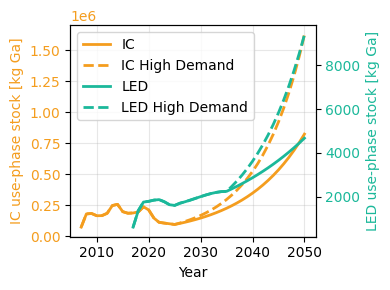

In [63]:
import matplotlib.pyplot as plt

fig, ax_ic = plt.subplots(1, 1, figsize=(4, 3))
ax_led = ax_ic.twinx()  # LED on a secondary Y-axis so it can scale independently

stock_scenarios = {
    "BAU": "",
    "High Demand": " High Demand",
}
scenario_linestyles = {
    "BAU": "-",
    "High Demand": "--",
}
product_colors = {
    "IC": "#f49d1e",
    "LED": "#1bb89a",
}
product_axes = {
    "IC": ax_ic,
    "LED": ax_led,
}
handles = []
for product in product_colors:
    for key, scenario_label in stock_scenarios.items():
        stock = scenario_results[key]["use_phase_stock_by_product"][product]
        (line,) = product_axes[product].plot(
            stock.index,
            stock.values,
            label=f"{product}{scenario_label}",
            color=product_colors[product],
            linestyle=scenario_linestyles[key],
            linewidth=2,
        )
        handles.append(line)
ax_ic.set_xlabel("Year")
ax_ic.set_ylabel("IC use-phase stock [kg Ga]", color=product_colors["IC"])
ax_led.set_ylabel("LED use-phase stock [kg Ga]", color=product_colors["LED"])
ax_ic.tick_params(axis="y", labelcolor=product_colors["IC"])
ax_led.tick_params(axis="y", labelcolor=product_colors["LED"])
ax_ic.legend(handles=handles, labels=[h.get_label() for h in handles])
ax_ic.grid(True, alpha=0.3)

fig.tight_layout()
# Save as .svg: plots/total_use_phase_stock.svg
plt.savefig("plots/total_use_phase_stock.svg", format="svg", dpi=1000)
plt.show()

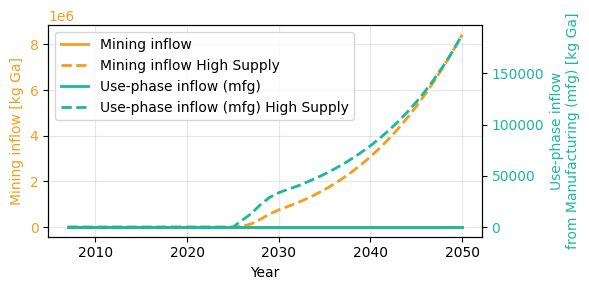

In [64]:
import matplotlib.pyplot as plt

fig, ax_mining = plt.subplots(1, 1, figsize=(6, 3))
ax_mfg = (
    ax_mining.twinx()
)  # Manufacturing inflow on a secondary Y-axis so it can scale independently

flow_scenarios = {
    "BAU": "",
    "High Supply": " High Supply",
}
scenario_linestyles = {
    "BAU": "-",
    "High Supply": "--",
}
metric_colors = {
    "Mining inflow": "#f49d1e",
    "Use-phase inflow (mfg)": "#1bb89a",
}
metric_axes = {
    "Mining inflow": ax_mining,
    "Use-phase inflow (mfg)": ax_mfg,
}


def mining_inflow(df):
    # Inflow into the Mining stage, summed across products.
    sel = df[(df["flow_type"] == "inflow") & (df["stage_name"] == "Mining")]
    return sel.groupby("year")["value_kg"].sum()


def use_phase_inflow_from_manufacturing(df):
    # Manufacturing (stage 5) product flow into the Use phase, summed across products.
    sel = df[
        (df["flow_type"] == "outflow_product")
        & (df["stage_name"] == "Manufacturing")
        & (df["target_stage_number"] == use_phase_stage_number)
    ]
    return sel.groupby("year")["value_kg"].sum()


metric_series = {
    "Mining inflow": mining_inflow,
    "Use-phase inflow (mfg)": use_phase_inflow_from_manufacturing,
}

handles = []
for metric in metric_colors:
    for key, scenario_label in flow_scenarios.items():
        series = metric_series[metric](scenario_results[key]["lifecycle_flows_df"])
        (line,) = metric_axes[metric].plot(
            series.index,
            series.values,
            label=f"{metric}{scenario_label}",
            color=metric_colors[metric],
            linestyle=scenario_linestyles[key],
            linewidth=2,
        )
        handles.append(line)

ax_mining.set_xlabel("Year")
ax_mining.set_ylabel("Mining inflow [kg Ga]", color=metric_colors["Mining inflow"])
ax_mfg.set_ylabel(
    "Use-phase inflow\nfrom Manufacturing (mfg) [kg Ga]",
    color=metric_colors["Use-phase inflow (mfg)"],
)
ax_mining.tick_params(axis="y", labelcolor=metric_colors["Mining inflow"])
ax_mfg.tick_params(axis="y", labelcolor=metric_colors["Use-phase inflow (mfg)"])
ax_mining.legend(handles=handles, labels=[h.get_label() for h in handles])
ax_mining.grid(True, alpha=0.3)

fig.tight_layout()
# Save as .svg: plots/mining_vs_manufacturing_inflow.svg
plt.savefig("plots/mining_vs_manufacturing_inflow.svg", format="svg", dpi=1000)
plt.show()

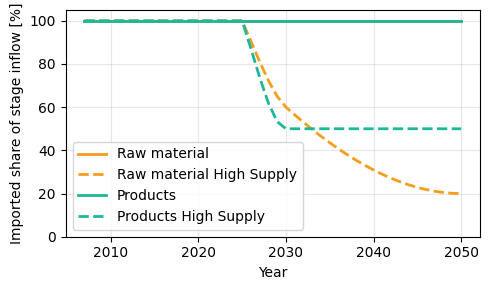

In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(5, 3))
import_scenarios = {
    "BAU": "",
    "High Supply": " High Supply",
}
# Status Quo should be #f49d1e
# Made in EU should be #1bb89a
scenario_linestyles = {
    "BAU": "-",
    "High Supply": "--",
}
import_type = {
    "raw_import_fraction": {
        "display_name": "Raw material",
        "color": "#f49d1e",
    },
    "product_import_fraction": {
        "display_name": "Products",
        "color": "#1bb89a",
    },
}
for key, label in import_type.items():
    for scenario_key, scenario_label in import_scenarios.items():
        res = scenario_results[scenario_key]
        # IC and LED share the same fractions here; average across products for one line.
        data = pd.concat(res[key], axis=1).mean(axis=1)
        linestyle = scenario_linestyles[scenario_key]
        axes.plot(
            data.index,
            data.values * 100,
            color=label["color"],
            linestyle=linestyle,
            linewidth=2,
            label=f"{label['display_name']}{scenario_label}",
        )
# axes.set_title("Import fraction")
axes.set_xlabel("Year")
axes.set_ylabel("Imported share of stage inflow [%]")
axes.set_ylim(0, 105)
axes.legend()
axes.grid(True, alpha=0.3)
fig.tight_layout()

# Save as .svg: plots/import_fraction.svg
plt.savefig("plots/import_fraction.svg", format="svg", dpi=1000)

plt.show()